In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

pd.set_option('display.max_rows', None)
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

In [2]:
import duckdb

con = duckdb.connect()
con.execute("""
    CREATE OR REPLACE VIEW loans AS 
    SELECT * FROM read_csv_auto('accepted_cleaned_v1.csv')
""")
con.sql("SELECT COUNT(*) FROM loans").show() # 2,139,958 나오면 정상

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│      2139958 │
└──────────────┘



> # 이자수익(int_rate) 관련

- 연도별로 이자율이 다른가? (경기상황 반영 여부)
- 등급별로 이자율이 균등하게 다른가?
- 이자율 결정에 등급 외 다른 요인이 존재하나?
- 년도별 기대 이자 수익 vs 실제 이자 수익

**올바른 기대이자 = 원리금균등분할 공식으로 계산한 총이자**

    월상환액 = P × mr × (1+mr)^n / ((1+mr)^n - 1)
    총이자 = 월상환액×n - P  (mr=월이자율, n=개월수)

## 연도별로 이자율이 다른가? (경기상황 반영 여부)

In [3]:
df = con.sql('''
    SELECT issue_year,
        COUNT(*) AS n,
        ROUND(AVG(int_rate), 2) AS avg_int_rate,
        ROUND(MEDIAN(int_rate), 2) AS median_int_rate,
        ROUND(STDDEV(int_rate), 2) AS stddev_int_rate
    FROM loans
    GROUP BY issue_year
    ORDER BY issue_year
''').df()
df

,issue_year,n,avg_int_rate,median_int_rate,stddev_int_rate
0,2007,603,11.83,11.54,2.73
1,2008,2393,12.06,11.91,2.53
2,2009,5281,12.44,12.53,2.67
3,2010,12537,11.99,11.86,3.49
4,2011,21721,12.22,11.99,4.15
5,2012,53367,13.64,13.67,4.37
6,2013,134814,14.53,14.33,4.44
7,2014,235629,13.77,13.65,4.33
8,2015,420584,12.60,12.29,4.32
9,2016,425618,13.02,11.99,4.93


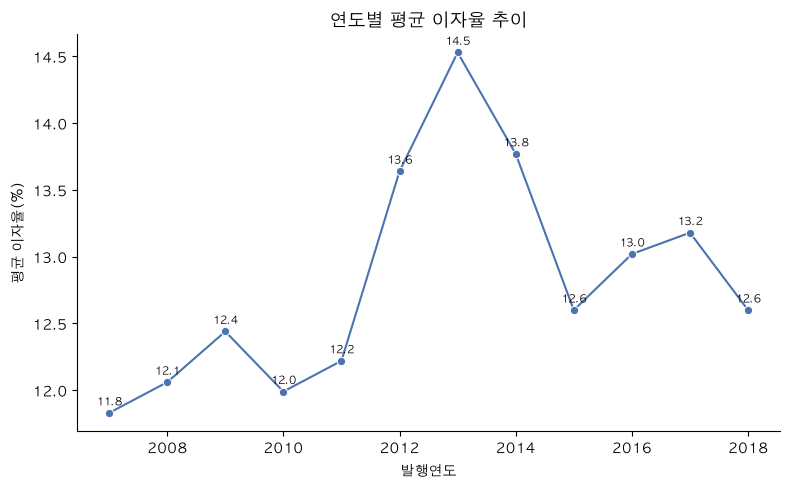

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.lineplot(
    data=df, x='issue_year', y='avg_int_rate',
    color= '#4C72B0',
    marker='o', ax=ax
)

for x, y in zip(df["issue_year"], df["avg_int_rate"]):
    ax.text(
        x,
        y + 0.03,          # 점보다 약간 위
        f"{y:.1f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

ax.set_title('연도별 평균 이자율 추이', fontsize=13)
ax.set_xlabel('발행연도')
ax.set_ylabel('평균 이자율(%)')
sns.despine(ax=ax)   # 불필요한 테두리 제거, 군더더기 최소화

plt.tight_layout()
plt.show()

## 등급별로 이자율이 균등하게 다른가?

In [14]:
df2 = con.sql('''
    SELECT
        issue_year, 
        grade, 
        sub_grade, 
        COUNT(*) AS cnt, 
        ROUND(AVG(int_rate), 2) AS avg_int_rate, 
        ROUND(MEDIAN(int_rate), 2) AS med_int_rate, 
        ROUND(STDDEV(int_rate), 2) AS stddev_int_rate
    FROM loans
    GROUP BY issue_year, grade, sub_grade
    ORDER BY issue_year, grade, sub_grade
''').df()
df2

,issue_year,grade,sub_grade,cnt,avg_int_rate,med_int_rate,stddev_int_rate
0,2007,A,A1,6,7.12,7.12,0.0
1,2007,A,A2,26,7.43,7.43,0.0
2,2007,A,A3,17,7.75,7.75,0.0
3,2007,A,A4,18,8.07,8.07,0.0
4,2007,A,A5,11,8.38,8.38,0.0
...,...,...,...,...,...,...,...
415,2018,G,G1,265,30.79,30.79,0.0
416,2018,G,G2,77,30.84,30.84,0.0
417,2018,G,G3,34,30.89,30.89,0.0
418,2018,G,G4,21,30.94,30.94,0.0


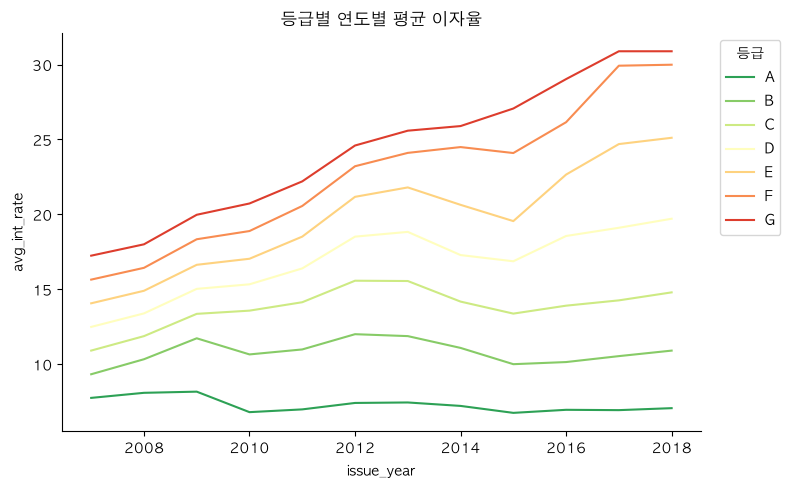

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))

palette = sns.color_palette("RdYlGn_r", 7)
sns.lineplot(
    data=df2,
    x='issue_year',
    y='avg_int_rate',
    hue='grade',
    palette=palette,
    ax=ax, 
    errorbar=None
)
sns.despine(ax=ax)

ax.set_title('등급별 연도별 평균 이자율')
ax.legend(title='등급', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

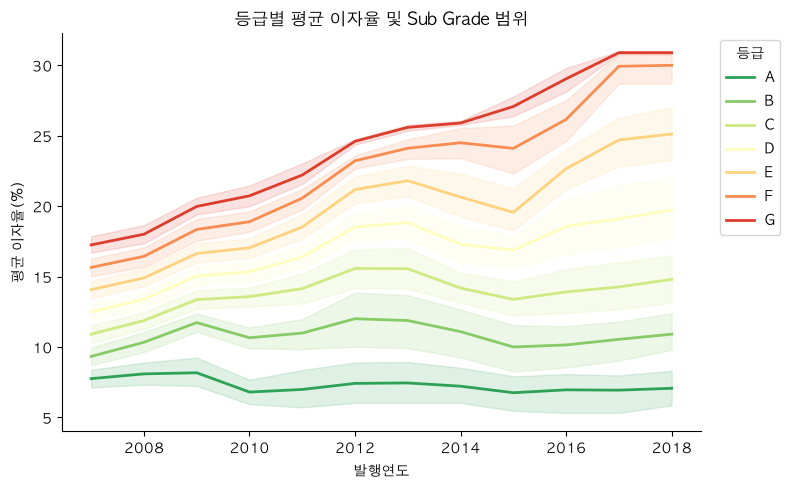

In [19]:
ribbon = (
    df2
    .groupby(['issue_year', 'grade'])['avg_int_rate']
    .agg(
        mean='mean',
        min='min',
        max='max'
    )
    .reset_index()
)
fig, ax = plt.subplots(figsize=(8,5))

palette = dict(zip(
    sorted(ribbon.grade.unique()),
    sns.color_palette("RdYlGn_r", 7)
))

for grade, d in ribbon.groupby("grade"):

    ax.plot(
        d["issue_year"],
        d["mean"],
        color=palette[grade],
        label=grade,
        linewidth=2
    )

    ax.fill_between(
        d["issue_year"],
        d["min"],
        d["max"],
        color=palette[grade],
        alpha=0.15
    )

sns.despine(ax=ax)

ax.set_title("등급별 평균 이자율 및 Sub Grade 범위")
ax.set_xlabel("발행연도")
ax.set_ylabel("평균 이자율(%)")

ax.legend(
    title="등급",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## 이자율 결정에 등급 외 다른 요인이 존재하나?

- 1단계 (sub_grade만): stddev 평균 1.55 → 등급만으로는 이자율 설명 부족

- 2단계 (+issue_year): stddev 평균 0.42로 급감 (1.55→0.42) → 연도(경기상황)가 핵심 설명변수

- 3단계 (+term): stddev 0.43, 변화 없음 → term은 추가 설명력 없음

**raw correlation (feature vs int_rate): fico_range 계열이 가장 강함(-0.42), revol_util(+0.26)/inq_last_6mths(+0.19)/dti(+0.19) 순**
**→ 단, 등급 자체가 이 변수들로 매겨졌을 가능성 있어 "새 발견"인지 "등급의 재확인"인지는 잔차로 재검증 필요**

- 범주형 boxplot: verification_status만 뚜렷한 차이(11→12.5→14). home_ownership은 신뢰 가능한 3개 카테고리(MORTGAGE/RENT/OWN) 기준 약함
- (NONE n=51, OTHER n=182로 표본 과소, 신뢰 불가). emp_length는 카테고리 간 차이 없음

**잔차(등급+연도 통제 후) correlation: dti/revol_util/inq/fico 전부 |r|<0.02 → 등급+연도에 이미 흡수된 정보, 등급 밖 추가요인 없음**

**잔차 기준 verification_status: 그룹간 avg_resid 차이가 residual stddev의 3% 수준 → 실질적 차이 없음**
**raw correlation에서 보였던 차이는 verification_status가 등급 배정과 얽혀 있어 나타난 간접효과였음**

### 결론: sub_grade + issue_year가 int_rate를 사실상 전부 설명. "등급 외 다른 요인" 없음

In [30]:
# 1단계: sub_grade만으로 이자율이 거의 고정되는지
df3 = con.sql('''
    SELECT
        sub_grade, 
        COUNT(*) AS cnt,
        ROUND(AVG(int_rate), 3) AS avg_int_rate, 
        ROUND(STDDEV(int_rate), 3) AS stddev_int_rate
    FROM loans
    GROUP BY sub_grade
    ORDER BY sub_grade
''').df()
df3['stddev_int_rate'].mean()

np.float64(1.5513142857142856)

In [31]:
# 2단계: sub_grade + issue_year로 좁혀보기
df4 = con.sql('''
    SELECT 
        sub_grade, 
        issue_year, 
        COUNT(*) AS cnt,
        ROUND(AVG(int_rate), 3) AS avg_int_rate,
        ROUND(STDDEV(int_rate), 3) AS stddev_int_rate
    FROM loans
    GROUP BY sub_grade, issue_year
    ORDER BY sub_grade, issue_year
''').df()
df4['stddev_int_rate'].mean()

np.float64(0.42346666666666666)

In [33]:
# 2단계: sub_grade + issue_year + term
df5 = con.sql('''
    SELECT 
        sub_grade, 
        issue_year, 
        term, 
        COUNT(*) AS cnt,
        ROUND(AVG(int_rate), 3) AS avg_int_rate,
        ROUND(STDDEV(int_rate), 3) AS stddev_int_rate
    FROM loans
    GROUP BY sub_grade, issue_year, term
    ORDER BY sub_grade, issue_year, term
''').df()
df5['stddev_int_rate'].mean()

np.float64(0.4327454289732771)

In [34]:
numeric_features = [
    'dti', 'revol_util', 'annual_inc', 'delinq_2yrs', 'inq_last_6mths',
    'open_acc', 'pub_rec', 'total_acc', 'revol_bal', 'mort_acc',
    'fico_range_low', 'fico_range_high'
]

sample = con.sql(f"""
    SELECT int_rate, {', '.join(numeric_features)}
    FROM loans
    USING SAMPLE 300000
""").df()

corr_with_rate = (
    sample.corr(numeric_only=True)['int_rate']
    .drop('int_rate')
    .sort_values(key=abs, ascending=False)
)
corr_with_rate

fico_range_low    -0.414798
fico_range_high   -0.414796
revol_util         0.259853
inq_last_6mths     0.192442
dti                0.185578
mort_acc          -0.086965
annual_inc        -0.077236
delinq_2yrs        0.056253
pub_rec            0.051516
total_acc         -0.041101
revol_bal         -0.026827
open_acc          -0.011859
Name: int_rate, dtype: float64

/var/folders/qk/8r3stcsx71zcypl_p65c_8q40000gn/T/ipykernel_76777/1597063281.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=corr_df, y='feature', x='corr', palette=colors, ax=ax)


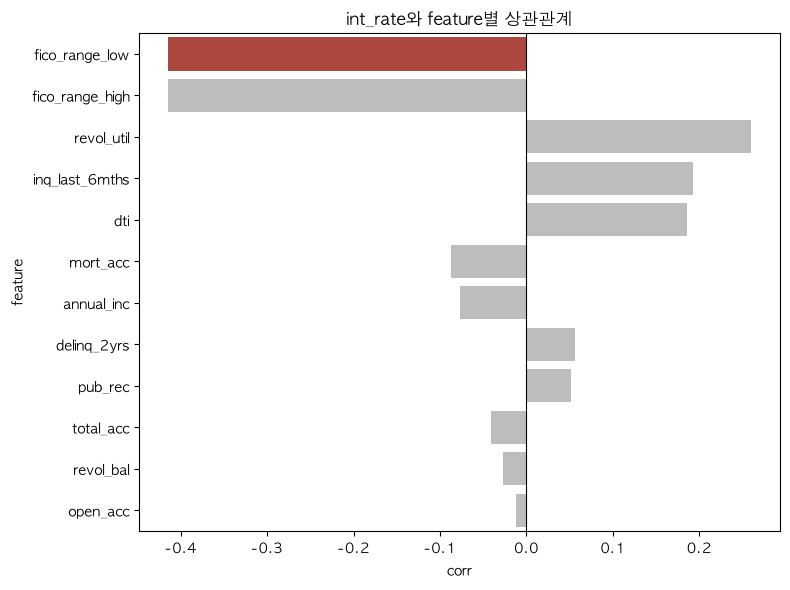

In [35]:
corr_df = corr_with_rate.reset_index()
corr_df.columns = ['feature', 'corr']
top_feature = corr_df.loc[corr_df['corr'].abs().idxmax(), 'feature']
colors = ['#c0392b' if f == top_feature else '#bdbdbd' for f in corr_df['feature']]

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=corr_df, y='feature', x='corr', palette=colors, ax=ax)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('int_rate와 feature별 상관관계')
plt.tight_layout()
plt.show()

In [37]:
con.sql("""
    SELECT home_ownership, COUNT(*) AS n
    FROM loans
    GROUP BY home_ownership
    ORDER BY n DESC
""").show()

┌────────────────┬─────────┐
│ home_ownership │    n    │
│    varchar     │  int64  │
├────────────────┼─────────┤
│ MORTGAGE       │ 1031582 │
│ RENT           │  865525 │
│ OWN            │  241623 │
│ ANY            │     995 │
│ OTHER          │     182 │
│ NONE           │      51 │
└────────────────┴─────────┘



In [38]:
con.sql("""
    SELECT verification_status, COUNT(*) AS n
    FROM loans
    GROUP BY verification_status
    ORDER BY n DESC
""").show()

┌─────────────────────┬────────┐
│ verification_status │   n    │
│       varchar       │ int64  │
├─────────────────────┼────────┤
│ Source Verified     │ 851935 │
│ Not Verified        │ 700202 │
│ Verified            │ 587821 │
└─────────────────────┴────────┘



In [39]:
con.sql("""
    SELECT emp_length, COUNT(*) AS n
    FROM loans
    GROUP BY emp_length
    ORDER BY n DESC
""").show()

┌────────────┬────────┐
│ emp_length │   n    │
│  varchar   │ int64  │
├────────────┼────────┤
│ 10+ years  │ 714464 │
│ 2 years    │ 194839 │
│ 3 years    │ 172785 │
│ < 1 year   │ 167907 │
│ 1 year     │ 142364 │
│ 5 years    │ 133536 │
│ 4 years    │ 130624 │
│ NULL       │ 130357 │
│ 6 years    │  98460 │
│ 7 years    │  89307 │
│ 8 years    │  88634 │
│ 9 years    │  76681 │
└────────────┴────────┘
  12 rows   2 columns



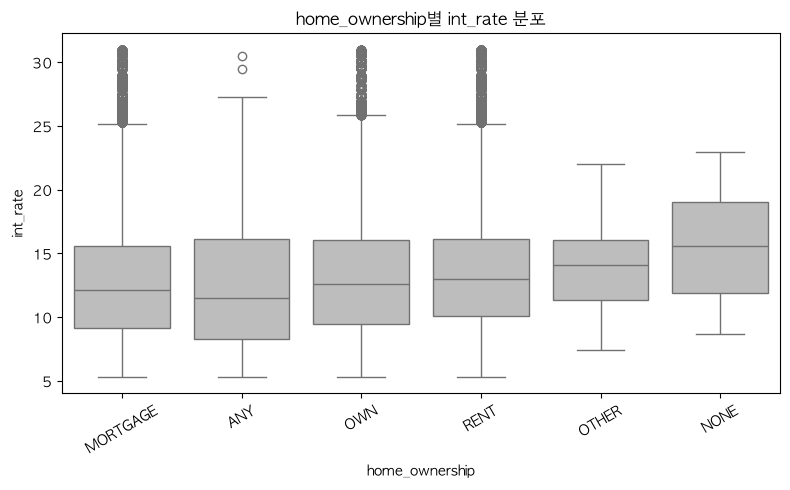

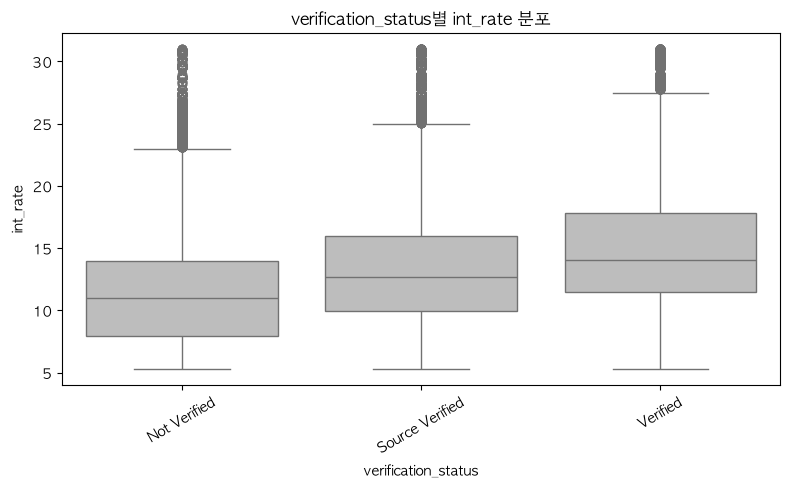

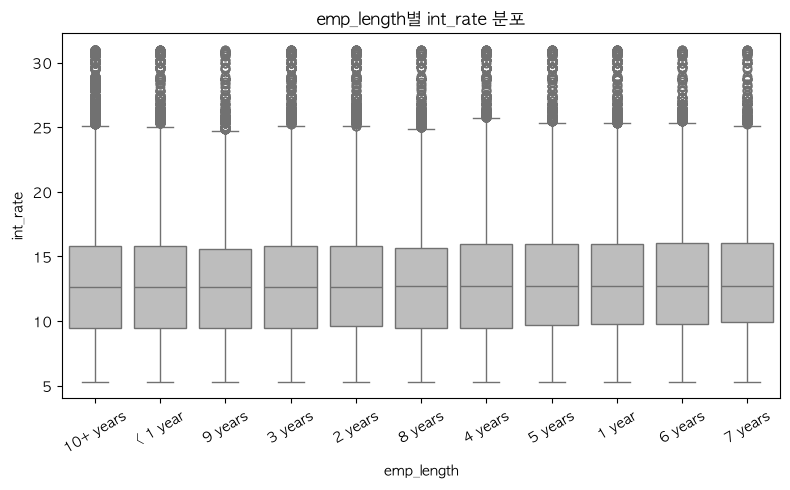

In [36]:
cat_sample = con.sql("""
    SELECT int_rate, home_ownership, verification_status, emp_length
    FROM loans
    USING SAMPLE 300000
""").df()

for col in ['home_ownership', 'verification_status', 'emp_length']:
    fig, ax = plt.subplots(figsize=(8, 5))
    order = cat_sample.groupby(col)['int_rate'].mean().sort_values().index
    sns.boxplot(data=cat_sample, x=col, y='int_rate', order=order, color='#bdbdbd', ax=ax)
    ax.set_title(f'{col}별 int_rate 분포')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

In [40]:
con.sql("""
    WITH residual AS (
        SELECT *,
               int_rate - AVG(int_rate) OVER (PARTITION BY sub_grade, issue_year) AS int_rate_resid
        FROM loans
    )
    SELECT
        CORR(int_rate_resid, dti)          AS corr_dti,
        CORR(int_rate_resid, revol_util)   AS corr_revol_util,
        CORR(int_rate_resid, inq_last_6mths) AS corr_inq,
        CORR(int_rate_resid, (fico_range_low + fico_range_high)/2.0) AS corr_fico
    FROM residual
""").show()

┌──────────────────────┬─────────────────────────┬───────────────────────┬───────────────────────┐
│       corr_dti       │     corr_revol_util     │       corr_inq        │       corr_fico       │
│        double        │         double          │        double         │        double         │
├──────────────────────┼─────────────────────────┼───────────────────────┼───────────────────────┤
│ -0.01872249696133382 │ -0.00016028693533214536 │ 0.0042075237566656385 │ -0.005117871680683918 │
└──────────────────────┴─────────────────────────┴───────────────────────┴───────────────────────┘



In [41]:
con.sql("""
    WITH residual AS (
        SELECT *,
               int_rate - AVG(int_rate) OVER (PARTITION BY sub_grade, issue_year) AS int_rate_resid
        FROM loans
    )
    SELECT verification_status, COUNT(*) AS n,
           ROUND(AVG(int_rate_resid), 4) AS avg_resid,
           ROUND(STDDEV(int_rate_resid), 4) AS stddev_resid
    FROM residual
    GROUP BY verification_status
    ORDER BY avg_resid DESC
""").show()

┌─────────────────────┬────────┬───────────┬──────────────┐
│ verification_status │   n    │ avg_resid │ stddev_resid │
│       varchar       │ int64  │  double   │    double    │
├─────────────────────┼────────┼───────────┼──────────────┤
│ Verified            │ 587821 │    0.0062 │       0.4858 │
│ Not Verified        │ 700202 │    0.0013 │       0.3625 │
│ Source Verified     │ 851935 │   -0.0053 │       0.4316 │
└─────────────────────┴────────┴───────────┴──────────────┘



## 년도별 기대 이자 수익 vs 실제 이자 수익 (funded_amnt × int_rate × term/12)

In [42]:
income_compare = con.sql("""
    SELECT issue_year,
        COUNT(*) AS n,
        ROUND(AVG(funded_amnt * int_rate/100.0 * 
                CAST(REGEXP_EXTRACT(term, '\\d+') AS INTEGER)/12.0), 2) AS expected_interest,
        ROUND(AVG(total_rec_int), 2) AS actual_interest,
        ROUND(AVG(total_rec_int) / AVG(funded_amnt * int_rate/100.0 * 
                CAST(REGEXP_EXTRACT(term, '\\d+') AS INTEGER)/12.0) * 100, 1) AS actual_pct_of_expected
    FROM loans
    WHERE loan_status = 'Fully Paid'
    GROUP BY issue_year
    ORDER BY issue_year
""").df()
income_compare

,issue_year,n,expected_interest,actual_interest,actual_pct_of_expected
0,2007,206,2569.75,1173.56,45.7
1,2008,1315,2839.03,1347.98,47.5
2,2009,4122,3634.02,1671.93,46.0
3,2010,10049,4393.37,1995.76,45.4
4,2011,18424,6058.00,2654.62,43.8
5,2012,44723,6810.32,3002.92,44.1
6,2013,113780,7887.87,3386.91,42.9
7,2014,181941,7255.59,2896.34,39.9
8,2015,299440,6359.67,2357.03,37.1
9,2016,220871,6449.72,1985.03,30.8


In [43]:
prepayment_check = con.sql("""
    SELECT issue_year,
           CAST(REGEXP_EXTRACT(term, '\\d+') AS INTEGER) AS nominal_term,
           ROUND(AVG(DATE_DIFF('month', 
                 STRPTIME(issue_d, '%b-%Y'), 
                 STRPTIME(last_pymnt_d, '%b-%Y'))), 1) AS avg_actual_months
    FROM loans
    WHERE loan_status = 'Fully Paid'
    GROUP BY issue_year, term
    ORDER BY issue_year, term
""").df()
prepayment_check

,issue_year,nominal_term,avg_actual_months
0,2007,36,28.7
1,2008,36,29.5
2,2009,36,28.1
3,2010,36,28.0
4,2010,60,41.9
5,2011,36,27.7
6,2011,60,39.7
7,2012,36,27.3
8,2012,60,36.6
9,2013,36,26.0


36개월 대출이 정상적으로 만기까지 가려면 발행 후 36개월이 지나야 하는데, 
관측기간이 2019년 3월에서 끊기니까 2016년 3월 이후 발행된 36개월 대출, 
2014년 3월 이후 발행된 60개월 대출은 정상 스케줄대로면 아직 만기가 안 된 상태

근데 이런 대출 중 일부가 벌써 Fully Paid로 잡혀있다는 건, 
그게 정상 상환이 아니라 극단적으로 빨리 갚아버린 케이스만 관측된 것이라는 뜻

In [44]:
con.sql("""
    SELECT issue_year,
           COUNT(*) AS n,
           ROUND(100.0 * SUM(CASE WHEN loan_status = 'Current' THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_current,
           ROUND(100.0 * SUM(CASE WHEN loan_status = 'Fully Paid' THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_fully_paid,
           ROUND(100.0 * SUM(CASE WHEN loan_status = 'Charged Off' THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_charged_off
    FROM loans
    GROUP BY issue_year
    ORDER BY issue_year
""").df()

,issue_year,n,pct_current,pct_fully_paid,pct_charged_off
0,2007,603,0.0,34.2,7.5
1,2008,2393,0.0,55.0,10.3
2,2009,5281,0.0,78.1,11.2
3,2010,12537,0.0,80.2,11.9
4,2011,21721,0.0,84.8,15.2
5,2012,53367,0.0,83.8,16.2
6,2013,134814,0.0,84.4,15.6
7,2014,235629,5.1,77.2,17.5
8,2015,420584,10.3,71.2,18.0
9,2016,425618,30.7,51.9,15.7


In [45]:
matured_check = con.sql("""
    WITH matured AS (
        SELECT *,
               STRPTIME(issue_d, '%b-%Y') AS issue_date,
               CAST(REGEXP_EXTRACT(term, '\\d+') AS INTEGER) AS term_months
        FROM loans
    )
    SELECT term, issue_year,
           COUNT(*) AS n,
           ROUND(AVG(funded_amnt * int_rate/100.0 * term_months/12.0), 2) AS expected_interest,
           ROUND(AVG(total_rec_int), 2) AS actual_interest,
           ROUND(AVG(total_rec_int) / AVG(funded_amnt * int_rate/100.0 * term_months/12.0) * 100, 1) AS realization_pct
    FROM matured
    WHERE loan_status = 'Fully Paid'
      AND DATE_ADD(issue_date, INTERVAL (term_months) MONTH) <= DATE '2019-03-01'
    GROUP BY term, issue_year
    ORDER BY term, issue_year
""").df()
matured_check

,term,issue_year,n,expected_interest,actual_interest,realization_pct
0,36 months,2007,206,2569.75,1173.56,45.7
1,36 months,2008,1315,2839.03,1347.98,47.5
2,36 months,2009,4122,3634.02,1671.93,46.0
3,36 months,2010,7624,3246.25,1496.34,46.1
4,36 months,2011,12602,3031.98,1383.16,45.6
5,36 months,2012,37567,4475.70,2064.58,46.1
6,36 months,2013,88044,4850.74,2181.47,45.0
7,36 months,2014,140255,4496.04,1976.67,44.0
8,36 months,2015,240698,4127.78,1799.76,43.6
9,36 months,2016,74155,4290.61,1817.98,42.4


In [46]:
realization_factor = con.sql("""
    WITH matured AS (
        SELECT *,
               STRPTIME(issue_d, '%b-%Y') AS issue_date,
               CAST(REGEXP_EXTRACT(term, '\\d+') AS INTEGER) AS term_months
        FROM loans
    )
    SELECT term,
           COUNT(*) AS n,
           ROUND(AVG(funded_amnt * int_rate/100.0 * term_months/12.0), 2) AS expected_interest,
           ROUND(AVG(total_rec_int), 2) AS actual_interest,
           ROUND(AVG(total_rec_int) / AVG(funded_amnt * int_rate/100.0 * term_months/12.0) * 100, 1) AS realization_pct
    FROM matured
    WHERE loan_status = 'Fully Paid'
      AND DATE_ADD(issue_date, INTERVAL (term_months) MONTH) <= DATE '2019-03-01'
    GROUP BY term
""").df()
realization_factor

,term,n,expected_interest,actual_interest,realization_pct
0,60 months,50711,17027.17,7009.81,41.2
1,36 months,606588,4318.79,1900.17,44.0


## 이자수익 계산방식 확정 (원리금균등분할상환 기준)
- naive 공식(funded_amnt × int_rate × term/12)은 불릿(bullet)/예금식 가정이라 
  실제 대비 약 2배 이상 과대추정됨을 확인 (원인 분해: 할부상환 구조 자체 55~58%, 여기에 조기상환 추가)
- 올바른 기대이자 = 원리금균등분할 공식으로 계산한 총이자
    월상환액 = P × mr × (1+mr)^n / ((1+mr)^n - 1),  총이자 = 월상환액×n - P  (mr=월이자율, n=개월수)
- term별 최종 조기상환 보정계수 (만기 지난 Fully Paid 대출만, 관측마감 2019-03 기준):

    36개월: amortized 대비 실현률 80.7% (naive 대비 최종 43.9%)
    
    60개월: amortized 대비 실현률 70.6% (naive 대비 최종 41.2%)
- term 길수록 조기상환 영향 더 큼 → 등급별 차이도 아래에서 확인

In [ ]:
result = con.sql("""
    WITH matured AS (
        SELECT *,
               STRPTIME(issue_d, '%b-%Y') AS issue_date,
               CAST(REGEXP_EXTRACT(term, '\\d+') AS INTEGER) AS term_months,
               int_rate/100.0/12.0 AS mr
        FROM loans
    ),
    amortized AS (
        SELECT *,
               funded_amnt * mr * POWER(1+mr, term_months) 
               / (POWER(1+mr, term_months) - 1) AS monthly_payment
        FROM matured
    )
    SELECT term,
           COUNT(*) AS n,
           ROUND(AVG(monthly_payment * term_months - funded_amnt), 2) AS expected_interest_amortized,
           ROUND(AVG(funded_amnt * int_rate/100.0 * term_months/12.0), 2) AS expected_interest_naive,
           ROUND(AVG(total_rec_int), 2) AS actual_interest,
           ROUND(AVG(total_rec_int) / AVG(monthly_payment * term_months - funded_amnt) * 100, 1) AS realization_pct_vs_amortized
    FROM amortized
    WHERE loan_status = 'Fully Paid'
      AND DATE_ADD(issue_date, INTERVAL (term_months) MONTH) <= DATE '2019-03-01'
    GROUP BY term
""").df()
result

,term,n,expected_interest_amortized,expected_interest_naive,actual_interest,realization_pct_vs_amortized
0,60 months,50711,9921.99,17027.17,7009.81,70.6
1,36 months,606588,2354.60,4318.79,1900.17,80.7


In [52]:
grade_realization = con.sql("""
    WITH matured AS (
        SELECT *,
               STRPTIME(issue_d, '%b-%Y') AS issue_date,
               CAST(REGEXP_EXTRACT(term, '\\d+') AS INTEGER) AS term_months,
               int_rate/100.0/12.0 AS mr
        FROM loans
    ),
    amortized AS (
        SELECT *,
               funded_amnt * mr * POWER(1+mr, term_months) 
               / (POWER(1+mr, term_months) - 1) AS monthly_payment
        FROM matured
    )
    SELECT TRIM(term) AS term, grade,
           COUNT(*) AS n,
           ROUND(AVG(monthly_payment * term_months - funded_amnt), 2) AS expected_interest_amortized,
           ROUND(AVG(total_rec_int), 2) AS actual_interest,
           ROUND(AVG(total_rec_int) / AVG(monthly_payment * term_months - funded_amnt) * 100, 1) AS realization_pct
    FROM amortized
    WHERE loan_status = 'Fully Paid'
      AND DATE_ADD(issue_date, INTERVAL (term_months) MONTH) <= DATE '2019-03-01'
    GROUP BY term, grade
    ORDER BY term, grade
""").df()
grade_realization

,term,grade,n,expected_interest_amortized,actual_interest,realization_pct
0,36 months,A,156462,1595.08,1335.75,83.7
1,36 months,B,214430,2163.82,1776.18,82.1
2,36 months,C,150340,2741.59,2186.82,79.8
3,36 months,D,64391,3397.85,2646.88,77.9
4,36 months,E,17186,3965.44,3018.17,76.1
5,36 months,F,3347,3951.34,2980.43,75.4
6,36 months,G,432,5507.98,3962.01,71.9
7,60 months,A,1114,3431.63,2636.87,76.8
8,60 months,B,7709,6068.06,4623.54,76.2
9,60 months,C,17455,8428.25,6195.21,73.5


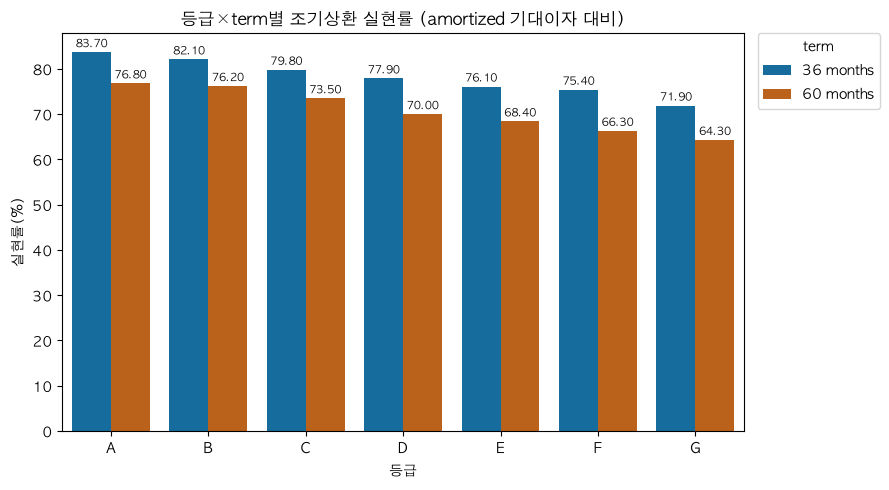

In [56]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=grade_realization, x='grade', y='realization_pct', hue='term',
    palette={'36 months': '#0072B2', '60 months': '#D55E00'}, ax=ax
)
ax.set_title('등급×term별 조기상환 실현률 (amortized 기대이자 대비)')
ax.set_ylabel('실현률(%)')
ax.set_xlabel('등급')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=1, fontsize=8)

ax.legend(title='term', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()

> # PD (feature) 관련

- feature 66개 기본 분포 확인
- 결측치가 구조적 결측인지, "이력없음" 결측인지 구분
    - (A) 구조적 결측: 데이터를 아예 수집 안 해서 값이 없음 (앞서 확인한 avg_cur_bal 같은 케이스)
    - (B) 이력없음 결측: 값을 잴 "사건" 자체가 없어서 (연체를 한 번도 안 한 사람은 "마지막 연체가 언제였나"를 계산할 방법이 없음)
- 등급별 실제 부도비율이 등급 순서와 비례하는가
- term(36/60개월)별 부도율 차이
- purpose(14종)별 부도율 차이 — 소수 카테고리(educational, renewable_energy 등)는 표본수 이슈 별도 고려
---
- 중복의심 feature 그룹 다중공선성 검증
- 상위 feature들의 비선형 관계 확인
- 클래스 불균형 확인 및 기록

In [5]:
con.execute("""
    CREATE OR REPLACE VIEW loans_pd AS
    SELECT *,
        CASE
            WHEN loan_status IN ('Default', 'Charged Off', 'Does not meet the credit policy. Status:Charged Off') THEN 1
            WHEN loan_status IN ('Fully Paid', 'Does not meet the credit policy. Status:Fully Paid') THEN 0
        END AS target
    FROM loans
    WHERE loan_status IN ('Default', 'Charged Off', 'Does not meet the credit policy. Status:Charged Off',
                           'Fully Paid', 'Does not meet the credit policy. Status:Fully Paid')
""")

## feature 파악

In [71]:
%pip install openpyxl
feature_list = [
    'acc_now_delinq','acc_open_past_24mths','annual_inc','avg_cur_bal','bc_open_to_buy','bc_util',
    'chargeoff_within_12_mths','collections_12_mths_ex_med','delinq_2yrs','delinq_amnt','dti',
    'earliest_cr_line','emp_length','fico_range_high','fico_range_low','grade','home_ownership',
    'inq_last_6mths','loan_amnt','mo_sin_old_il_acct','mo_sin_old_rev_tl_op','mo_sin_rcnt_rev_tl_op',
    'mo_sin_rcnt_tl','mort_acc','mths_since_last_delinq','mths_since_last_major_derog',
    'mths_since_last_record','mths_since_recent_bc','mths_since_recent_bc_dlq','mths_since_recent_inq',
    'mths_since_recent_revol_delinq','num_accts_ever_120_pd','num_actv_bc_tl','num_actv_rev_tl',
    'num_bc_sats','num_bc_tl','num_il_tl','num_op_rev_tl','num_rev_accts','num_rev_tl_bal_gt_0',
    'num_sats','num_tl_120dpd_2m','num_tl_30dpd','num_tl_90g_dpd_24m','num_tl_op_past_12m','open_acc',
    'pct_tl_nvr_dlq','percent_bc_gt_75','pub_rec','pub_rec_bankruptcies','purpose','revol_bal',
    'revol_util','sub_grade','tax_liens','term','tot_coll_amt','tot_cur_bal','tot_hi_cred_lim',
    'total_acc','total_bal_ex_mort','total_bc_limit','total_il_high_credit_limit','total_rev_hi_lim',
    'verification_status','issue_year'
]

# 1) 통계 프로파일링 (66개만)
profile = con.sql(f"SUMMARIZE SELECT {', '.join(feature_list)} FROM loans_pd").df()

# 2) 엑셀의 한글 설명 붙이기
col_meta = pd.read_excel('LendingClub_컬럼분류_최종v2.xlsx', sheet_name='column_classification')
col_meta = col_meta[col_meta['role'] == 'feature'][['column', '설명(한글)']]

profile_full = profile.merge(col_meta, left_on='column_name', right_on='column', how='left')

# 3) 측정 성격별 그룹 태깅
category_map = {
    '금액형': ['annual_inc','loan_amnt','avg_cur_bal','bc_open_to_buy','revol_bal','tot_coll_amt',
              'tot_cur_bal','tot_hi_cred_lim','total_bal_ex_mort','total_bc_limit',
              'total_il_high_credit_limit','total_rev_hi_lim','delinq_amnt'],
    '비율형': ['dti','bc_util','revol_util','pct_tl_nvr_dlq','percent_bc_gt_75'],
    '카운트형': ['acc_now_delinq','acc_open_past_24mths','chargeoff_within_12_mths','collections_12_mths_ex_med',
               'delinq_2yrs','inq_last_6mths','mort_acc','num_accts_ever_120_pd','num_actv_bc_tl',
               'num_actv_rev_tl','num_bc_sats','num_bc_tl','num_il_tl','num_op_rev_tl','num_rev_accts',
               'num_rev_tl_bal_gt_0','num_sats','num_tl_120dpd_2m','num_tl_30dpd','num_tl_90g_dpd_24m',
               'num_tl_op_past_12m','open_acc','pub_rec','pub_rec_bankruptcies','tax_liens','total_acc'],
    '개월수형': ['mo_sin_old_il_acct','mo_sin_old_rev_tl_op','mo_sin_rcnt_rev_tl_op','mo_sin_rcnt_tl',
               'mths_since_last_delinq','mths_since_last_major_derog','mths_since_last_record',
               'mths_since_recent_bc','mths_since_recent_bc_dlq','mths_since_recent_inq',
               'mths_since_recent_revol_delinq'],
    '신용점수형': ['fico_range_high','fico_range_low'],
    '범주형': ['emp_length','grade','sub_grade','home_ownership','purpose','term','verification_status'],
    '날짜형': ['earliest_cr_line'],
    '코호트': ['issue_year'],
}
feature_to_cat = {f: cat for cat, feats in category_map.items() for f in feats}
profile_full['성격'] = profile_full['column_name'].map(feature_to_cat)

profile_full = profile_full[['성격','column_name','설명(한글)','min','max','avg','std','q25','q50','q75','null_percentage','approx_unique']]
profile_full.sort_values(['성격','column_name'])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]1/2 [openpyxl]
Note: you may need to restart the kernel to use updated packages.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,성격,column_name,설명(한글),min,max,avg,std,q25,q50,q75,null_percentage,approx_unique
19,개월수형,mo_sin_old_il_acct,가장 오래된 할부(은행) 계좌 개설 후 경과 개월수,0.0,999.0,125.81319717138788,52.264261089574966,97.67712268779457,129.16910584890474,152.5189854239791,8.13,544
20,개월수형,mo_sin_old_rev_tl_op,가장 오래된 리볼빙 계좌 개설 후 경과 개월수,2.0,852.0,181.49424288507495,94.40883855857898,117.24486422032972,164.044836849469,230.21144270463097,5.31,746
21,개월수형,mo_sin_rcnt_rev_tl_op,가장 최근 개설된 리볼빙 계좌 개설 후 경과 개월수,0.0,438.0,13.08462112305274,16.284860511086183,3.9491499574617563,7.99917574813583,15.919166291137444,5.31,297
22,개월수형,mo_sin_rcnt_tl,가장 최근 개설된 계좌 개설 후 경과 개월수,0.0,314.0,7.850299157279813,8.710525100288521,3.0,5.402361334431717,9.99936224870831,5.31,211
24,개월수형,mths_since_last_delinq,마지막 연체 이후 경과 개월수,0.0,226.0,34.28863846042408,21.92563446026345,15.657280038050226,31.043852444013176,50.054885437471654,50.41,181
25,개월수형,mths_since_last_major_derog,가장 최근 90일 이상(또는 그 이상 심각한) 연체 이후 경과 개월수,0.0,226.0,43.66377745494297,21.373118818485246,26.62125386175677,43.63254201721401,61.12871848860195,73.71,191
26,개월수형,mths_since_last_record,마지막 공공기록(public record) 이후 경과 개월수,0.0,129.0,70.32511789305099,26.834417152271566,52.551067006520505,71.325797748464,90.16115237523687,83.00,165
27,개월수형,mths_since_recent_bc,가장 최근 개설된 신용카드 계좌 개설 후 경과 개월수,0.0,639.0,23.769113483592864,30.621377266265434,5.999439494537457,13.23401192491456,28.323463140433557,4.72,517
28,개월수형,mths_since_recent_bc_dlq,가장 최근 신용카드 연체 이후 경과 개월수,0.0,202.0,39.669679086385095,22.696710449821087,20.71727086878102,37.888144820570865,58.35281437693462,76.29,193
29,개월수형,mths_since_recent_inq,가장 최근 신용조회 이후 경과 개월수,0.0,25.0,6.712854218389302,5.850714331213864,2.0,5.0,9.999896072554716,13.18,28


In [78]:
pd.options.display.float_format = '{:.1f}'.format

# 핵심 컬럼만 추리고, 설명은 필요할 때 따로 찾아보는 걸로
summary_view = profile_full[['성격', 'column_name', '설명(한글)', 'min', 'q50', 'max', 'null_percentage', 'approx_unique']].copy()

for cat, group in summary_view.groupby('성격'):
    print(f"\n===== {cat} ({len(group)}개) =====")
    display(group.drop(columns='성격').style.hide(axis='index'))


===== 개월수형 (11개) =====


column_name,설명(한글),min,q50,max,null_percentage,approx_unique
mo_sin_old_il_acct,가장 오래된 할부(은행) 계좌 개설 후 경과 개월수,0.0,129.16910584890474,999.0,8.130000,544
mo_sin_old_rev_tl_op,가장 오래된 리볼빙 계좌 개설 후 경과 개월수,2.0,164.044836849469,852.0,5.310000,746
mo_sin_rcnt_rev_tl_op,가장 최근 개설된 리볼빙 계좌 개설 후 경과 개월수,0.0,7.99917574813583,438.0,5.310000,297
mo_sin_rcnt_tl,가장 최근 개설된 계좌 개설 후 경과 개월수,0.0,5.402361334431717,314.0,5.310000,211
mths_since_last_delinq,마지막 연체 이후 경과 개월수,0.0,31.043852444013176,226.0,50.410000,181
mths_since_last_major_derog,가장 최근 90일 이상(또는 그 이상 심각한) 연체 이후 경과 개월수,0.0,43.63254201721401,226.0,73.710000,191
mths_since_last_record,마지막 공공기록(public record) 이후 경과 개월수,0.0,71.325797748464,129.0,83.000000,165
mths_since_recent_bc,가장 최근 개설된 신용카드 계좌 개설 후 경과 개월수,0.0,13.23401192491456,639.0,4.720000,517
mths_since_recent_bc_dlq,가장 최근 신용카드 연체 이후 경과 개월수,0.0,37.888144820570865,202.0,76.290000,193
mths_since_recent_inq,가장 최근 신용조회 이후 경과 개월수,0.0,5.0,25.0,13.180000,28



===== 금액형 (13개) =====


column_name,설명(한글),min,q50,max,null_percentage,approx_unique
annual_inc,가입 시 자진 신고한 연간 소득,1896.0,65074.43789234517,10999200.0,0.000000,49880
avg_cur_bal,전체 계좌의 평균 현재 잔액,0.0,7332.359111353562,958084.0,5.320000,84723
bc_open_to_buy,리볼빙 신용카드(bankcard)의 총 사용 가능 한도,0.0,4702.673615280044,559912.0,4.790000,75713
delinq_amnt,현재 연체 중인 계좌의 연체 금액,0.0,0.0,249925.0,0.000000,2720
loan_amnt,신청자가 신청한 대출 금액(심사 중 감액되면 그 값이 반영됨),500.0,12013.099185069575,40000.0,0.000000,1432
revol_bal,총 리볼빙 신용 잔액,0.0,11137.836195686721,2904836.0,0.000000,91144
tot_coll_amt,지금까지 발생한 총 추심 금액,0.0,0.0,9152545.0,5.310000,13068
tot_cur_bal,전체 계좌의 총 현재 잔액,0.0,79188.89485599598,8000078.0,5.310000,363410
tot_hi_cred_lim,총 최고신용한도(high credit/credit limit),0.0,111333.36972900566,9999999.0,5.310000,381019
total_bal_ex_mort,주택담보대출을 제외한 총 신용 잔액,0.0,37237.78383941314,3408095.0,3.780000,174818



===== 날짜형 (1개) =====


...

column_name,설명(한글),min,q50,max,null_percentage,approx_unique
fico_range_high,대출 실행 시점 FICO 점수 구간의 상단값,614.0,693.9108205057477,850.0,0.000000,49
fico_range_low,대출 실행 시점 FICO 점수 구간의 하단값,610.0,689.9108205057477,845.0,0.000000,51



===== 카운트형 (26개) =====


column_name,설명(한글),min,q50,max,null_percentage,approx_unique
acc_now_delinq,현재 연체 중인 계좌의 수,0.0,0.0,14.0,0.000000,9
acc_open_past_24mths,최근 24개월 내 개설된 신용거래(trade) 수,0.0,4.0,64.0,3.780000,61
chargeoff_within_12_mths,최근 12개월 내 상각(charge-off) 처리된 계좌 수,0.0,0.0,10.0,0.010000,12
collections_12_mths_ex_med,"의료비 관련을 제외한, 최근 12개월 내 추심 건수",0.0,0.0,20.0,0.010000,16
delinq_2yrs,최근 2년간 30일 이상 연체 발생 건수,0.0,0.0,39.0,0.000000,30
inq_last_6mths,최근 6개월 내 신용조회 건수 (자동차·주택담보대출 조회 제외),0.0,0.0,33.0,0.000000,29
mort_acc,주택담보대출 계좌 수,0.0,1.0,51.0,3.780000,37
num_accts_ever_120_pd,120일 이상 연체 이력이 있었던 계좌 수,0.0,0.0,51.0,5.310000,39
num_actv_bc_tl,현재 활성 상태인 신용카드 계좌 수,0.0,3.0,35.0,5.310000,32
num_actv_rev_tl,현재 활성 상태인 리볼빙 계좌 수,0.0,5.0,63.0,5.310000,56



===== 코호트 (1개) =====


column_name,설명(한글),min,q50,max,null_percentage,approx_unique
issue_year,issue_d(대출실행월)에서 파생한 연도. 시계열 분할/코호트 분석용으로 보존,2007,2015,2018,0.000000,13


In [79]:
con.sql("""
    SELECT
        SUM(CASE WHEN tot_hi_cred_lim = 9999999 THEN 1 ELSE 0 END)      AS n_tot_hi_cred_lim_9999999,
        SUM(CASE WHEN total_rev_hi_lim = 9999999 THEN 1 ELSE 0 END)     AS n_total_rev_hi_lim_9999999,
        SUM(CASE WHEN mo_sin_old_il_acct = 999 THEN 1 ELSE 0 END)       AS n_mo_sin_old_il_acct_999,
        SUM(CASE WHEN dti < 0 THEN 1 ELSE 0 END)                        AS n_dti_negative,
        SUM(CASE WHEN annual_inc > 1000000 THEN 1 ELSE 0 END)           AS n_annual_inc_over_1m,
        SUM(CASE WHEN revol_util > 150 THEN 1 ELSE 0 END)               AS n_revol_util_over_150,
        SUM(CASE WHEN bc_util > 150 THEN 1 ELSE 0 END)                  AS n_bc_util_over_150,
        SUM(CASE WHEN STRPTIME(earliest_cr_line, '%b-%Y') < DATE '1960-01-01' THEN 1 ELSE 0 END) AS n_cr_line_pre1960,
        COUNT(*) AS total_n
    FROM loans_pd
""").df()

,n_tot_hi_cred_lim_9999999,n_total_rev_hi_lim_9999999,n_mo_sin_old_il_acct_999,n_dti_negative,n_annual_inc_over_1m,n_revol_util_over_150,n_bc_util_over_150,n_cr_line_pre1960,total_n
0,12.0,3.0,1.0,1.0,290.0,20.0,77.0,211.0,1322293


## 결측치가 구조적 결측인지, "이력없음" 결측인지 구분

In [63]:
missing_profile = con.sql("SUMMARIZE SELECT * FROM loans_pd").df()[['column_name', 'null_percentage']]
missing_profile = missing_profile.sort_values('null_percentage', ascending=False)
missing_profile

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,column_name,null_percentage
41,next_pymnt_d,99.79
101,orig_projected_additional_accrued_interest,99.72
102,hardship_payoff_balance_amount,99.58
91,hardship_reason,99.58
92,hardship_status,99.58
93,deferral_term,99.58
94,hardship_amount,99.58
96,hardship_end_date,99.58
97,payment_plan_start_date,99.58
98,hardship_length,99.58


mths_since_last_delinq, mths_since_last_record 같은 건 
구조적(수집 안 됨)이 아니라 "연체가 아예 없었던 사람이라 
'마지막 연체로부터 개월수'를 잴 대상 자체가 없는" 케이스일 가능성이 높음.

In [66]:
con.sql("""
    SELECT 
        CASE WHEN mths_since_last_delinq IS NULL THEN 'NULL' ELSE 'NOT NULL' END AS is_null,
        AVG(delinq_2yrs) AS avg_delinq_2yrs,
        COUNT(*) AS n
    FROM loans_pd
    GROUP BY is_null
""").df()

,is_null,avg_delinq_2yrs,n
0,NULL,0.009175,666528
1,NOT NULL,0.632022,655765


In [67]:
checks = [
    ('mths_since_last_major_derog', 'pub_rec'),
    ('mths_since_last_record', 'pub_rec'),
    ('mths_since_recent_bc_dlq', 'delinq_2yrs'),
    ('mths_since_recent_revol_delinq', 'delinq_2yrs'),
    ('mths_since_recent_inq', 'inq_last_6mths'),
]

for null_col, proxy_col in checks:
    result = con.sql(f"""
        SELECT 
            CASE WHEN {null_col} IS NULL THEN 'NULL' ELSE 'NOT NULL' END AS is_null,
            AVG({proxy_col}) AS avg_{proxy_col},
            COUNT(*) AS n
        FROM loans_pd
        GROUP BY is_null
    """).df()
    print(f"--- {null_col} vs {proxy_col} ---")
    print(result, '\n')

--- mths_since_last_major_derog vs pub_rec ---
    is_null  avg_pub_rec       n
0      NULL     0.193557  974678
1  NOT NULL     0.275880  347615 

--- mths_since_last_record vs pub_rec ---
    is_null  avg_pub_rec        n
0  NOT NULL     1.265904   224780
1      NULL     0.000000  1097513 

--- mths_since_recent_bc_dlq vs delinq_2yrs ---
    is_null  avg_delinq_2yrs        n
0  NOT NULL         0.804476   313480
1      NULL         0.166920  1008813 

--- mths_since_recent_revol_delinq vs delinq_2yrs ---
    is_null  avg_delinq_2yrs       n
0      NULL         0.100383  880411
1  NOT NULL         0.751780  441882 

--- mths_since_recent_inq vs inq_last_6mths ---
    is_null  avg_inq_last_6mths        n
0      NULL            0.298725   174343
1  NOT NULL            0.721479  1147950 



In [68]:
con.sql("""
    SELECT 
        CASE WHEN mths_since_last_major_derog IS NULL THEN 'NULL' ELSE 'NOT NULL' END AS is_null,
        AVG(pub_rec_bankruptcies) AS avg_bankruptcies,
        AVG(num_accts_ever_120_pd) AS avg_120pd_accts,
        AVG(chargeoff_within_12_mths) AS avg_chargeoff_12m,
        COUNT(*) AS n
    FROM loans_pd
    GROUP BY is_null
""").df()

,is_null,avg_bankruptcies,avg_120pd_accts,avg_chargeoff_12m,n
0,NULL,0.128642,0.018521,0.000591,974678
1,NOT NULL,0.148535,1.790912,0.032988,347615


In [64]:
numeric_features = [
    'acc_now_delinq','acc_open_past_24mths','annual_inc','avg_cur_bal','bc_open_to_buy','bc_util',
    'chargeoff_within_12_mths','collections_12_mths_ex_med','delinq_2yrs','delinq_amnt','dti',
    'fico_range_high','fico_range_low','inq_last_6mths','loan_amnt','mo_sin_old_il_acct',
    'mo_sin_old_rev_tl_op','mo_sin_rcnt_rev_tl_op','mo_sin_rcnt_tl','mort_acc','mths_since_last_delinq',
    'mths_since_last_major_derog','mths_since_last_record','mths_since_recent_bc','mths_since_recent_bc_dlq',
    'mths_since_recent_inq','mths_since_recent_revol_delinq','num_accts_ever_120_pd','num_actv_bc_tl',
    'num_actv_rev_tl','num_bc_sats','num_bc_tl','num_il_tl','num_op_rev_tl','num_rev_accts',
    'num_rev_tl_bal_gt_0','num_sats','num_tl_120dpd_2m','num_tl_30dpd','num_tl_90g_dpd_24m',
    'num_tl_op_past_12m','open_acc','pct_tl_nvr_dlq','percent_bc_gt_75','pub_rec','pub_rec_bankruptcies',
    'revol_bal','revol_util','tax_liens','tot_coll_amt','tot_cur_bal','tot_hi_cred_lim','total_acc',
    'total_bal_ex_mort','total_bc_limit','total_il_high_credit_limit','total_rev_hi_lim'
]

corr_expr = ',\n    '.join([f'CORR(target, {f}) AS {f}' for f in numeric_features])
corr_result = con.sql(f"SELECT\n    {corr_expr}\nFROM loans_pd").df().T.reset_index()
corr_result.columns = ['feature', 'corr_with_target']
corr_result = corr_result.reindex(corr_result['corr_with_target'].abs().sort_values(ascending=False).index)
corr_result

,feature,corr_with_target
12,fico_range_low,-0.132145
11,fico_range_high,-0.132143
10,dti,0.108719
1,acc_open_past_24mths,0.101526
40,num_tl_op_past_12m,0.087044
4,bc_open_to_buy,-0.082014
3,avg_cur_bal,-0.078869
51,tot_hi_cred_lim,-0.077840
19,mort_acc,-0.074761
29,num_actv_rev_tl,0.071966


In [65]:
categorical_features = ['grade', 'sub_grade', 'home_ownership', 'purpose', 'verification_status', 'term', 'emp_length']

cat_summary = []
for col in categorical_features:
    df = con.sql(f"SELECT {col}, AVG(target) AS default_rate, COUNT(*) AS n FROM loans_pd GROUP BY {col}").df()
    cat_summary.append({'feature': col, 'default_rate_spread': df['default_rate'].max() - df['default_rate'].min(), 'n_categories': len(df)})

pd.DataFrame(cat_summary).sort_values('default_rate_spread', ascending=False)

,feature,default_rate_spread,n_categories
1,sub_grade,0.493754,35
0,grade,0.435359,7
3,purpose,0.172466,14
5,term,0.165585,2
4,verification_status,0.091452,3
6,emp_length,0.078844,12
2,home_ownership,0.074278,6


## 등급별 부도 비율

In [80]:
grade_default = con.sql("""
    SELECT grade, COUNT(*) AS n,
           ROUND(AVG(target) * 100, 2) AS default_rate_pct
    FROM loans_pd
    GROUP BY grade
    ORDER BY grade
""").df()
grade_default

,grade,n,default_rate_pct
0,A,231732,6.0
1,B,386733,13.4
2,C,374037,22.4
3,D,196980,30.3
4,E,92205,38.4
5,F,31599,45.1
6,G,9007,49.5


/var/folders/qk/8r3stcsx71zcypl_p65c_8q40000gn/T/ipykernel_76777/3676952086.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


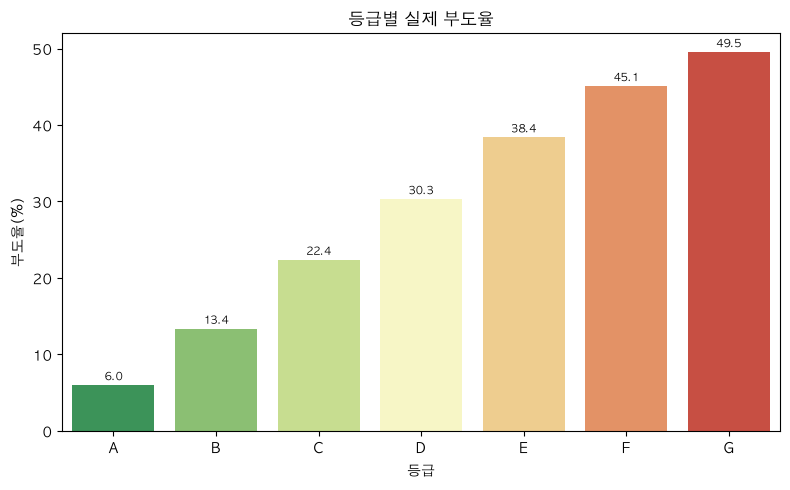

In [87]:
palette = sns.color_palette("RdYlGn_r", 7)
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=grade_default,
    x='grade',
    y='default_rate_pct',
    palette=palette,
    ax=ax
)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=1, fontsize=8)
ax.set_title('등급별 실제 부도율')
ax.set_ylabel('부도율(%)')
ax.set_xlabel('등급')
plt.tight_layout()
plt.show()

/var/folders/qk/8r3stcsx71zcypl_p65c_8q40000gn/T/ipykernel_76777/1632195456.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=subgrade_default, x='sub_grade', y='default_rate_pct', palette=palette, ax=ax)


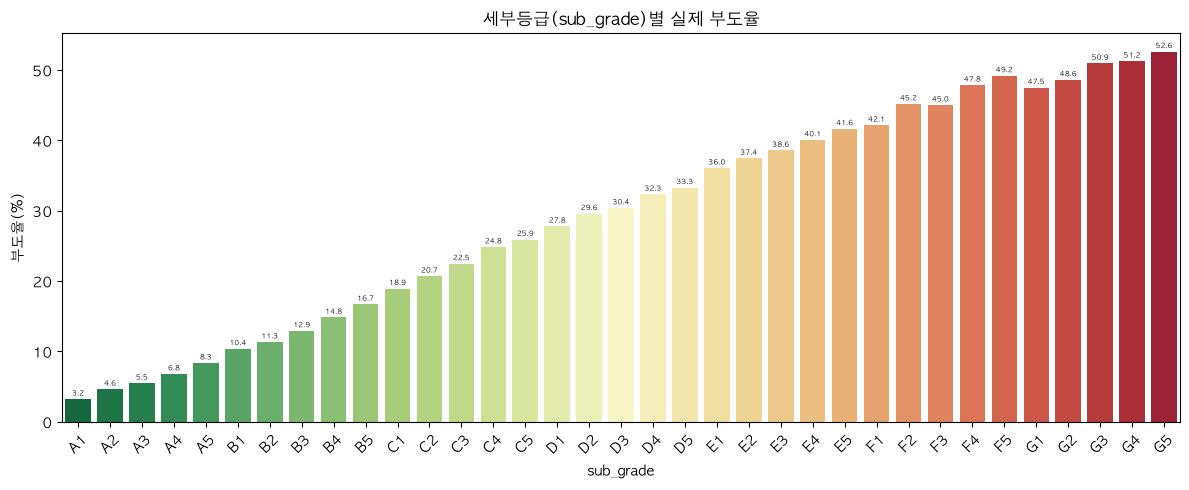

In [91]:
subgrade_default = con.sql("""
    SELECT sub_grade, COUNT(*) AS n,
           ROUND(AVG(target) * 100, 2) AS default_rate_pct
    FROM loans_pd
    GROUP BY sub_grade
    ORDER BY sub_grade
""").df()
palette = sns.color_palette("RdYlGn_r", 35)
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=subgrade_default, x='sub_grade', y='default_rate_pct', palette=palette, ax=ax)
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f',
        padding=1,
        fontsize=5
    )
ax.set_title('세부등급(sub_grade)별 실제 부도율')
ax.set_ylabel('부도율(%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## term(36/60개월)별 부도율 차이

## purpose(14종)별 부도율 차이

In [98]:
term_default = con.sql("""
    SELECT TRIM(term) AS term, COUNT(*) AS n, ROUND(AVG(target) * 100, 2) AS default_rate_pct
    FROM loans_pd
    GROUP BY term
    ORDER BY term
""").df()
term_default

,term,n,default_rate_pct
0,36 months,1006938,15.9
1,60 months,315355,32.5


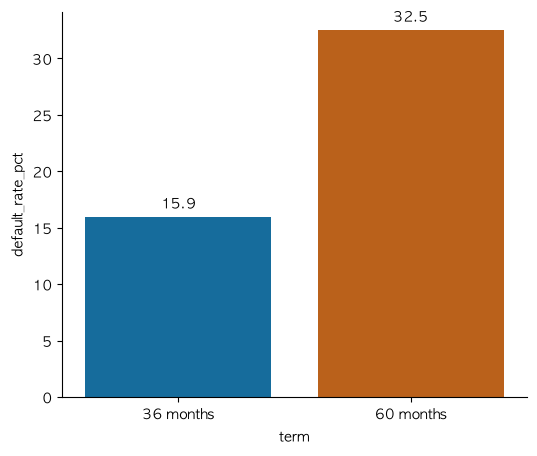

In [105]:
palette = {
    '36 months': '#0072B2',
    '60 months': '#D55E00'
}

fig, ax = plt.subplots(figsize=(6, 5))

sns.barplot(
    data=term_default,
    x='term',
    y='default_rate_pct',
    hue='term',          # 추가
    palette=palette,
    legend=False,        # 범례 제거
    ax=ax
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3)

sns.despine()
plt.show()

In [93]:
purpose_default = con.sql("""
    SELECT purpose, COUNT(*) AS n, ROUND(AVG(target) * 100, 2) AS default_rate_pct
    FROM loans_pd
    GROUP BY purpose
    ORDER BY default_rate_pct DESC
""").df()
purpose_default

,purpose,n,default_rate_pct
0,small_business,15341,29.7
1,renewable_energy,921,23.7
2,moving,9335,23.0
3,house,7130,21.9
4,medical,15157,21.6
5,debt_consolidation,765469,21.1
6,other,76855,20.9
7,educational,423,20.8
8,vacation,8953,19.1
9,major_purchase,29055,18.5


/var/folders/qk/8r3stcsx71zcypl_p65c_8q40000gn/T/ipykernel_76777/3330247508.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=purpose_default, x='purpose', y='default_rate_pct', order=order, palette=colors, ax=ax)


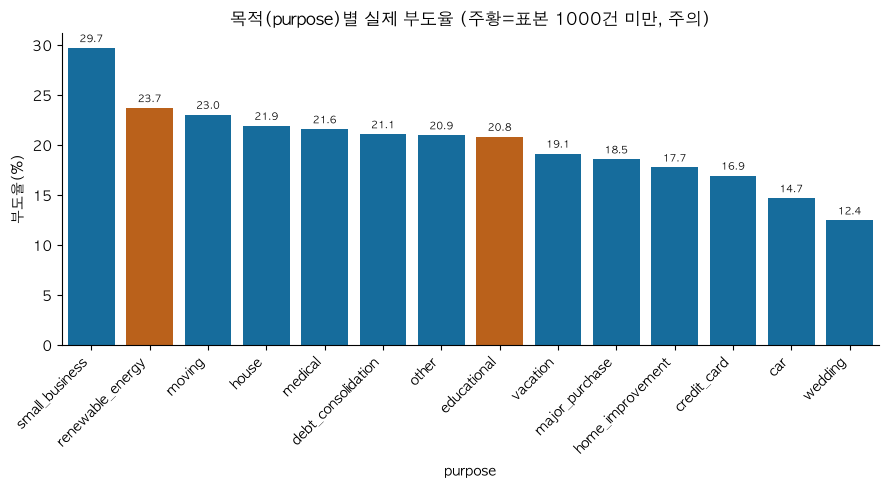

In [108]:
fig, ax = plt.subplots(figsize=(9, 5))
order = purpose_default.sort_values('default_rate_pct', ascending=False)['purpose']
colors = ['#D55E00' if n < 1000 else '#0072B2' for n in purpose_default.set_index('purpose').loc[order, 'n']]
sns.barplot(data=purpose_default, x='purpose', y='default_rate_pct', order=order, palette=colors, ax=ax)
ax.set_title('목적(purpose)별 실제 부도율 (주황=표본 1000건 미만, 주의)')
ax.set_ylabel('부도율(%)')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=2, fontsize=7)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
sns.despine()

plt.show()

## 중복의심 feature 그룹 다중공선성 검증

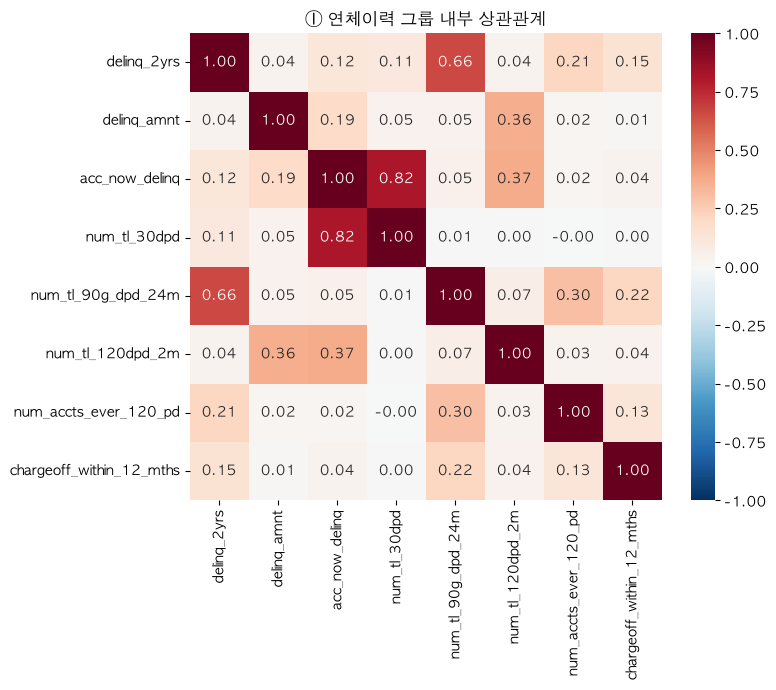

In [109]:
groups = {
    '①연체이력': ['delinq_2yrs', 'delinq_amnt', 'acc_now_delinq', 'num_tl_30dpd',
                'num_tl_90g_dpd_24m', 'num_tl_120dpd_2m', 'num_accts_ever_120_pd', 'chargeoff_within_12_mths'],
    '②계좌수': ['open_acc', 'total_acc', 'num_sats', 'num_bc_sats', 'num_actv_bc_tl', 'num_actv_rev_tl',
              'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0',
              'acc_open_past_24mths', 'num_tl_op_past_12m'],
    '③리볼빙': ['revol_bal', 'revol_util', 'bc_open_to_buy', 'bc_util', 'total_bc_limit',
              'total_rev_hi_lim', 'percent_bc_gt_75'],
    '④잔액한도': ['avg_cur_bal', 'tot_cur_bal', 'total_bal_ex_mort', 'tot_hi_cred_lim', 'total_il_high_credit_limit'],
    '⑤계좌나이': ['mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl'],
    '⑥최근사건': ['mths_since_recent_bc', 'mths_since_recent_inq'],
    '⑦공공기록': ['pub_rec', 'pub_rec_bankruptcies', 'mths_since_last_record', 'tax_liens'],
    '⑧신용점수': ['fico_range_low', 'fico_range_high', 'grade', 'sub_grade'],  # grade/sub_grade는 범주형이라 별도 처리 필요
}

sample = con.sql(f"SELECT {', '.join(groups['①연체이력'])} FROM loans_pd USING SAMPLE 300000").df()

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(sample.corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('① 연체이력 그룹 내부 상관관계')
plt.tight_layout()
plt.show()

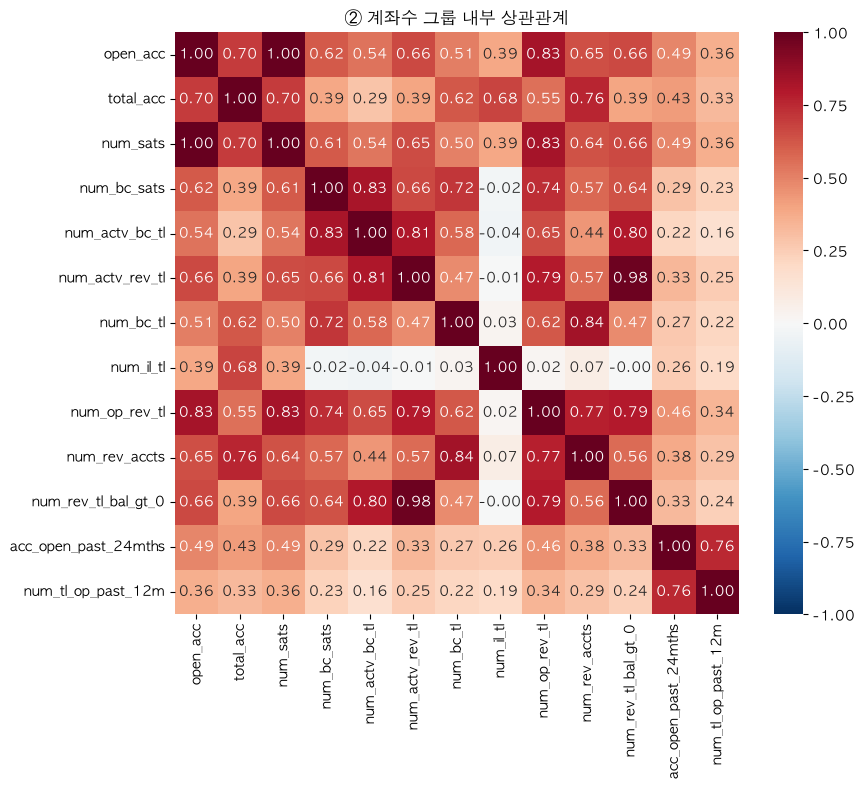

In [110]:
sample = con.sql(f"SELECT {', '.join(groups['②계좌수'])} FROM loans_pd USING SAMPLE 300000").df()

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(sample.corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('② 계좌수 그룹 내부 상관관계')
plt.tight_layout()
plt.show()

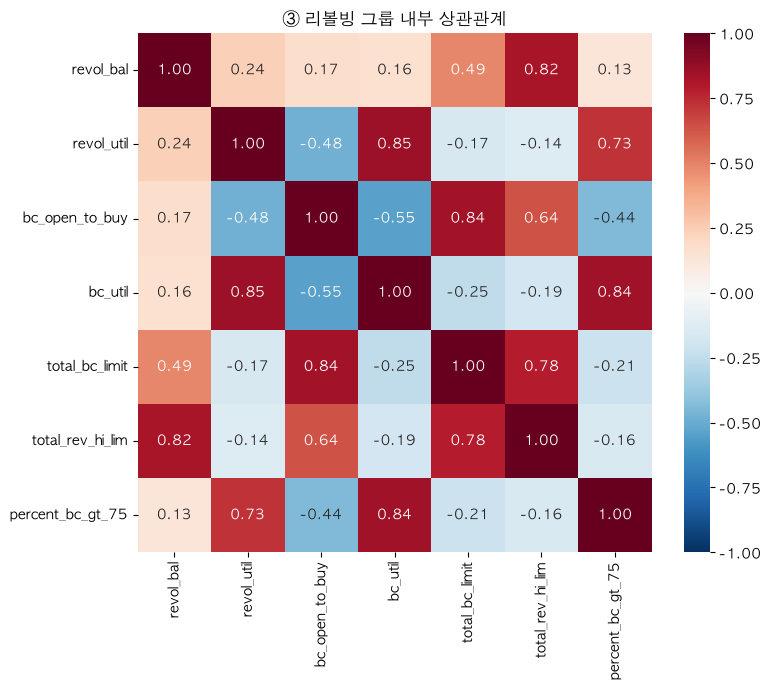

In [111]:
sample = con.sql(f"SELECT {', '.join(groups['③리볼빙'])} FROM loans_pd USING SAMPLE 300000").df()

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(sample.corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('③ 리볼빙 그룹 내부 상관관계')
plt.tight_layout()
plt.show()

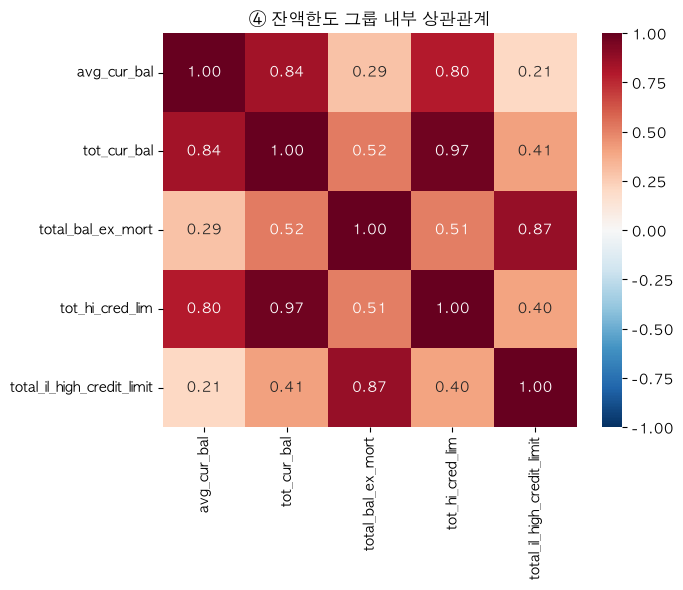

In [112]:
sample = con.sql(f"SELECT {', '.join(groups['④잔액한도'])} FROM loans_pd USING SAMPLE 300000").df()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(sample.corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('④ 잔액한도 그룹 내부 상관관계')
plt.tight_layout()
plt.show()

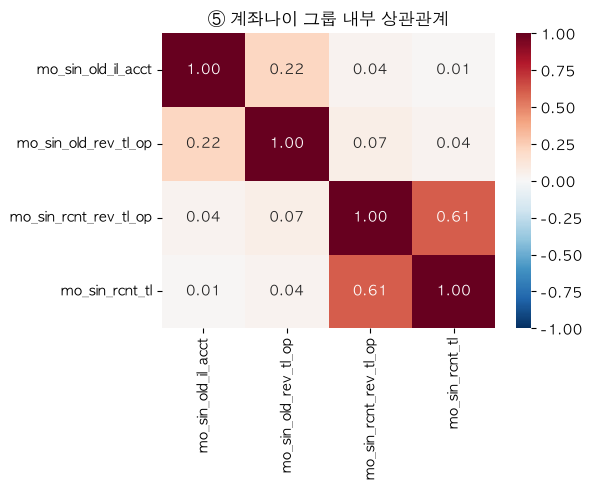

In [113]:
sample = con.sql(f"SELECT {', '.join(groups['⑤계좌나이'])} FROM loans_pd USING SAMPLE 300000").df()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(sample.corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('⑤ 계좌나이 그룹 내부 상관관계')
plt.tight_layout()
plt.show()

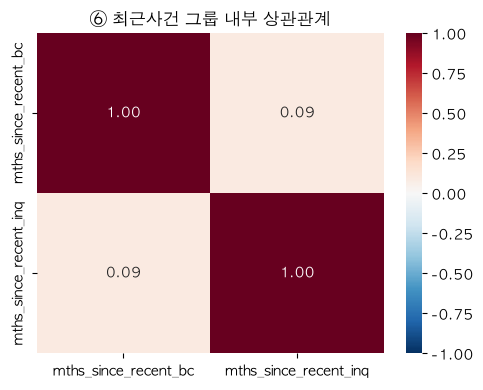

In [114]:
sample = con.sql(f"SELECT {', '.join(groups['⑥최근사건'])} FROM loans_pd USING SAMPLE 300000").df()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(sample.corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('⑥ 최근사건 그룹 내부 상관관계')
plt.tight_layout()
plt.show()

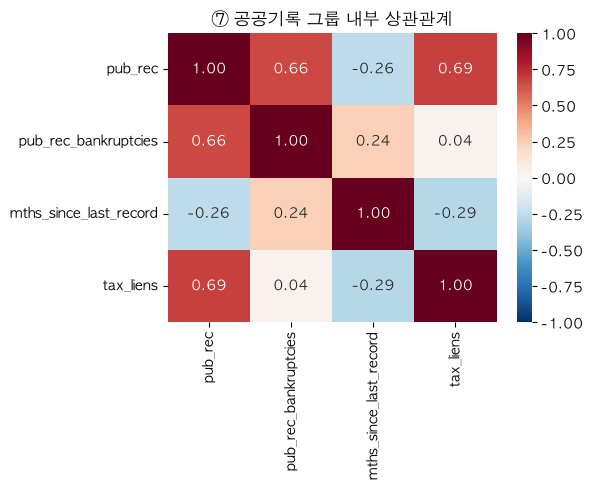

In [115]:
sample = con.sql(f"SELECT {', '.join(groups['⑦공공기록'])} FROM loans_pd USING SAMPLE 300000").df()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(sample.corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('⑦ 공공기록 그룹 내부 상관관계')
plt.tight_layout()
plt.show()

In [116]:
sample = con.sql("SELECT fico_range_low, fico_range_high FROM loans_pd USING SAMPLE 300000").df()
print(sample.corr())

                 fico_range_low  fico_range_high
fico_range_low              1.0              1.0
fico_range_high             1.0              1.0


## 상위 feature 비선형 관계 확인

**목적:** 지금까지 본 상관계수는 선형관계만 잡음.

dti나 fico처럼 특정 임계값을 넘으면 부도율이 급격히 뛰는 "문턱 효과"가 있을 수 있는데, 이건 상관계수로는 안 보임.

구간(10분위)별 실제 부도율을 찍어서 선형/비선형 패턴을 직접 확인.

**판단 기준**
1. 단조성 — 방향이 끝까지 한쪽으로만 가는지 확인. 중간에 방향 바뀌면(U자/역U자) 상관계수가 완전히 놓치는 패턴이므로 중요
2. 기울기 변화 — 특정 구간에서 갑자기 꺾이면 문턱효과 후보. 연속값보다 구간화/더미변수가 나을 수 있음
3. 양끝 급가속 여부 — 중간은 완만한데 최상위/최하위 분위에서만 급변하면, 선형계수 하나로 표현 시 정보손실 큼

**결과**
- dti, avg_fico, acc_open_past_24mths, bc_open_to_buy, num_actv_rev_tl, bc_util: 단조적이나 9→10분위에서 기울기 급가속 → 상관계수가 방향은 맞으나 최상위 극단구간 위험도를 과소평가하고 있을 가능성 있음
- mort_acc: 1~4분위 평평, 4→5분위에서 급격히 꺾임 → 문턱효과. "주택담보대출 보유 여부(0/1)" 이진화가 연속값보다 유효할 가능성
- avg_cur_bal: **유일하게 비단조(역U자형)**. 1분위→2~3분위 상승 후 지속 하락. 상관계수(-0.079)로는 포착 불가능한 패턴 → 별도 기록 필요, 구간화 고려 대상

**결론**: mort_acc, avg_cur_bal은 연속값 그대로 쓰기보다 구간화/이진화 검토 대상으로 표시. 나머지는 선형 항 유지하되 상위 10분위 더미 추가 고려.

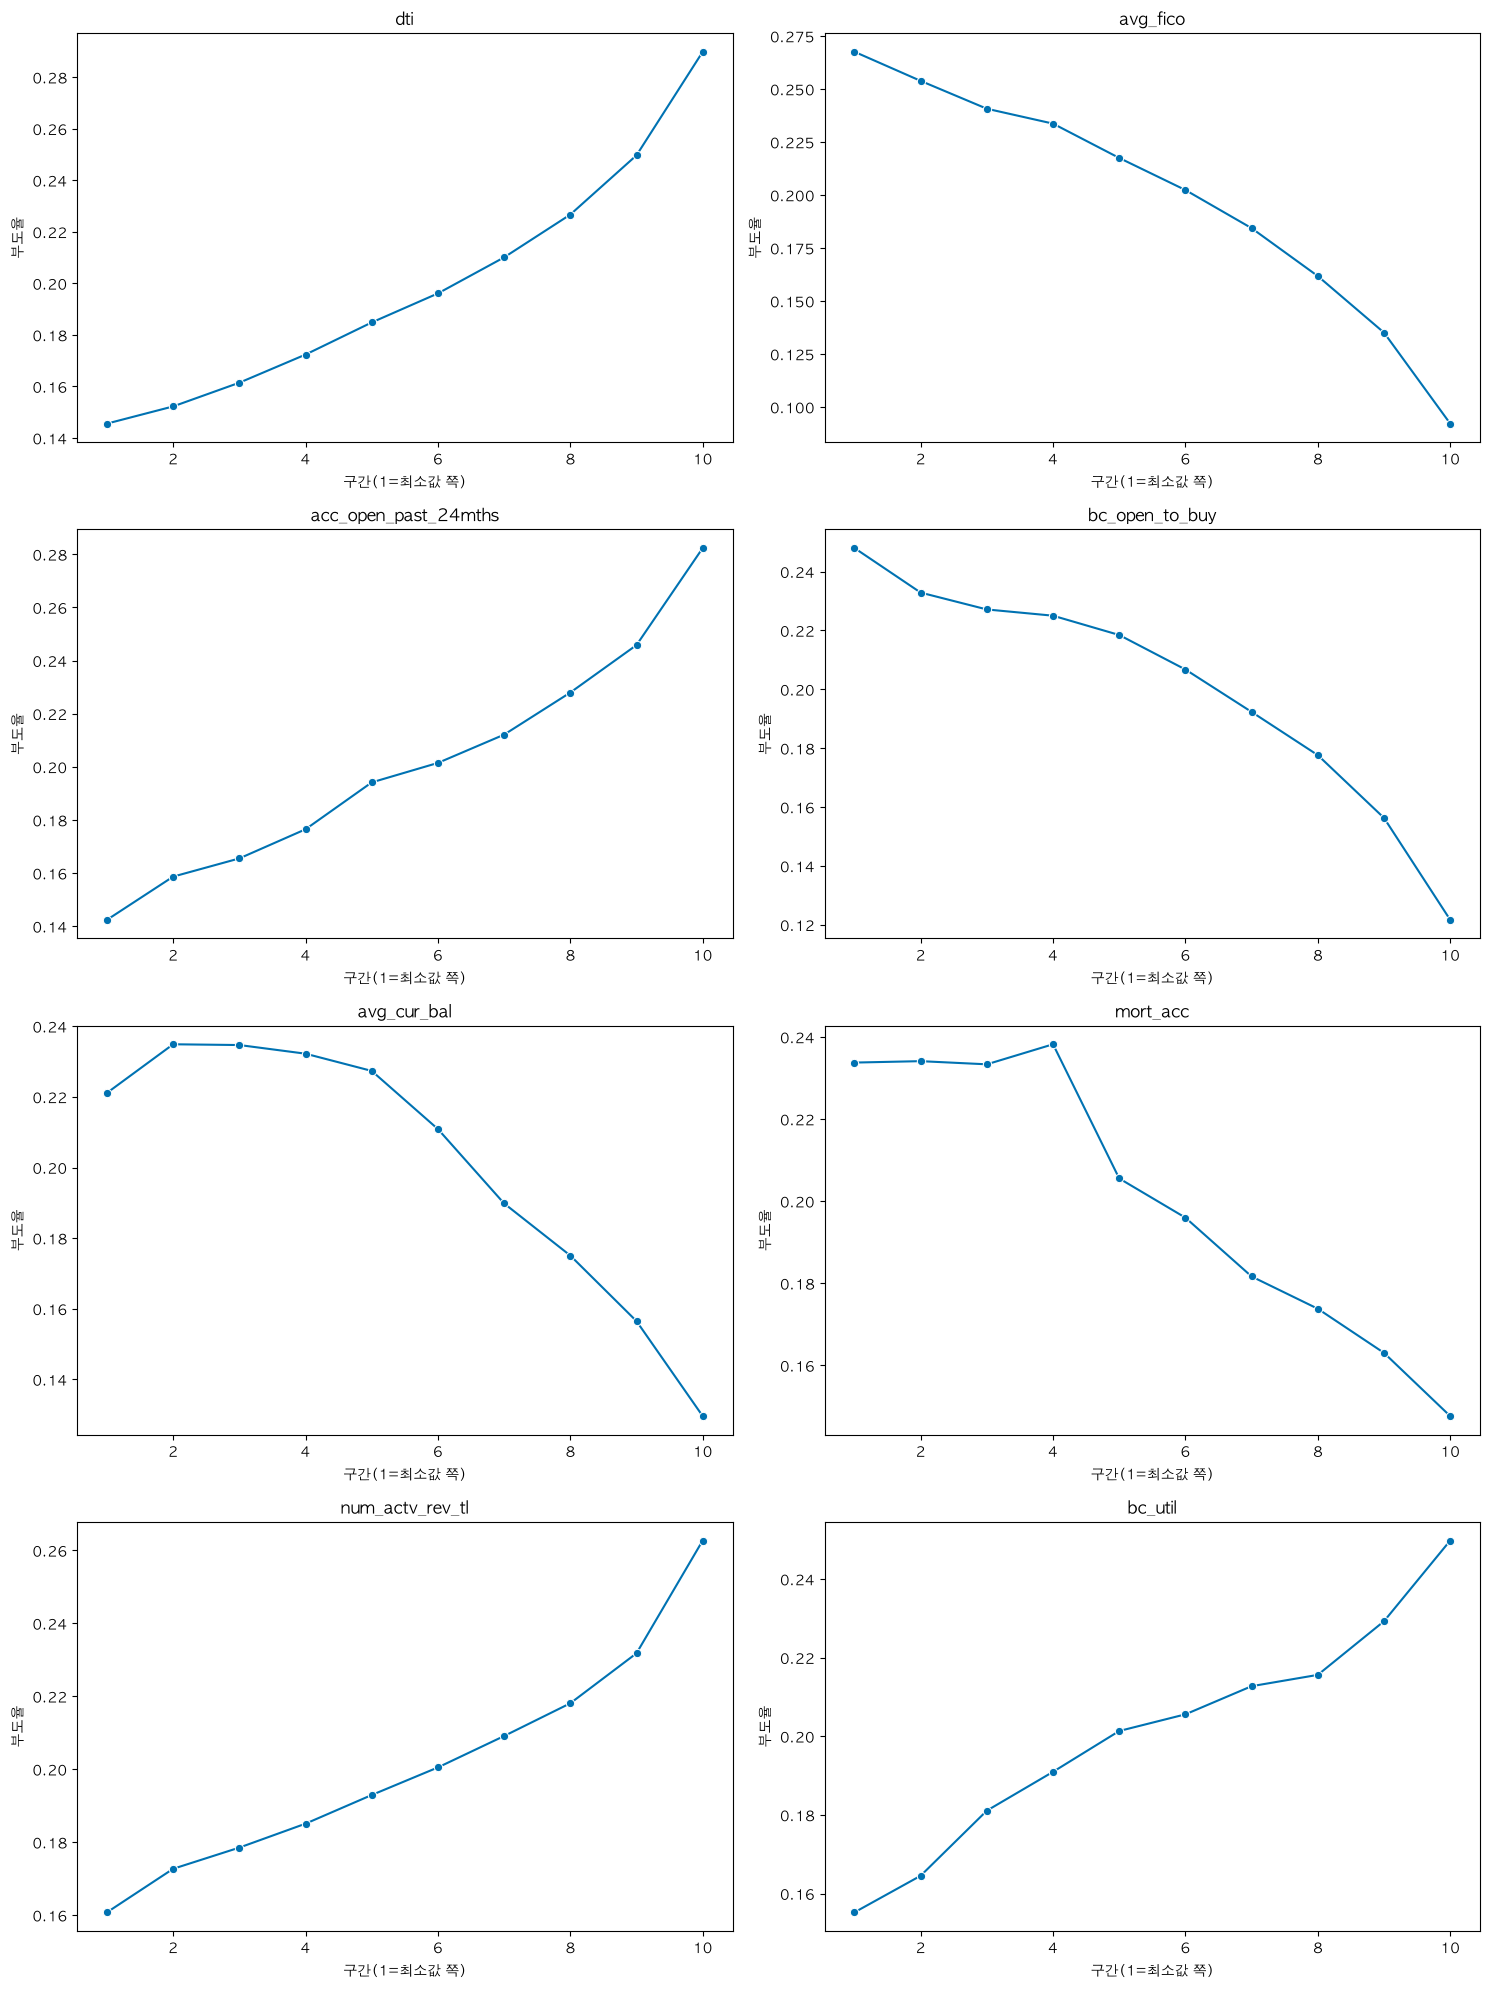

In [118]:
target_features = ['dti', 'avg_fico', 'acc_open_past_24mths', 'bc_open_to_buy', 
                    'avg_cur_bal', 'mort_acc', 'num_actv_rev_tl', 'bc_util']

fig, axes = plt.subplots(4, 2, figsize=(15, 20))
axes = axes.flatten()

for i, feat in enumerate(target_features):
    df = con.sql(f"""
        SELECT NTILE(10) OVER (ORDER BY {feat}) AS decile,
               {feat}, target
        FROM loans_pd2
        WHERE {feat} IS NOT NULL
    """).df()
    
    decile_summary = df.groupby('decile').agg(
        feat_mean=(feat, 'mean'),
        default_rate=('target', 'mean'),
        n=('target', 'size')
    ).reset_index()
    
    sns.lineplot(data=decile_summary, x='decile', y='default_rate', marker='o', color='#0072B2', ax=axes[i])
    axes[i].set_title(feat)
    axes[i].set_xlabel('구간(1=최소값 쪽)')
    axes[i].set_ylabel('부도율')

plt.tight_layout()
plt.show()

## 클래스 불균형 확인 및 기록

**목적:** target(부도) 비율이 얼마나 치우쳐있는지 명시적으로 확인. 나중에 모델링 단계에서 class weight·오버샘플링(SMOTE 등) 적용 여부를 결정하는 근거로 씀.

In [119]:
class_balance = con.sql("""
    SELECT target, COUNT(*) AS n,
           ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct
    FROM loans_pd
    GROUP BY target
    ORDER BY target
""").df()
class_balance

,target,n,pct
0,0,1059283,80.1
1,1,263010,19.9


/var/folders/qk/8r3stcsx71zcypl_p65c_8q40000gn/T/ipykernel_76777/3304135888.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['정상(0)', '부도(1)'])


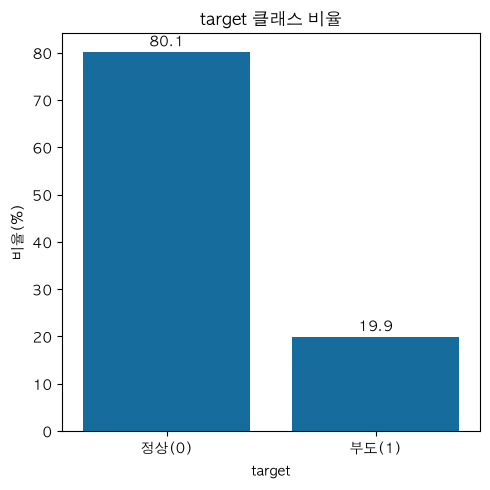

In [123]:
fig, ax = plt.subplots(figsize=(5, 5))
sns.barplot(data=class_balance, x='target', y='pct', color='#0072B2', ax=ax)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=1)
ax.set_title('target 클래스 비율')
ax.set_xticklabels(['정상(0)', '부도(1)'])
ax.set_ylabel('비율(%)')
plt.tight_layout()
plt.show()

> # LGD 관련

- issue_year(vintage)별, 등급별 recoveries 완결 정도 (censoring 확인 → seasoning cut-off 연도 결정용)
- 완결된 vintage 기준 손실율(LGD) 수준 파악

## issue_year(vintage)별, 등급별 recoveries 완결 정도 (censoring 확인 → seasoning cut-off 연도 결정용)

In [4]:
recovery_censoring = con.sql("""
    SELECT issue_year,
           COUNT(*) AS n_charged_off,
           ROUND(100.0 * SUM(CASE WHEN recoveries = 0 THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_zero_recovery,
           ROUND(AVG(recoveries), 2) AS avg_recoveries,
           ROUND(AVG(recoveries - collection_recovery_fee), 2) AS avg_net_recovery
    FROM loans
    WHERE loan_status IN ('Charged Off', 'Does not meet the credit policy. Status:Charged Off')
    GROUP BY issue_year
    ORDER BY issue_year
""").df()
recovery_censoring

,issue_year,n_charged_off,pct_zero_recovery,avg_recoveries,avg_net_recovery
0,2007,158,0.6,590.95,464.64
1,2008,496,3.0,465.57,356.24
2,2009,723,1.4,633.21,478.98
3,2010,1757,0.5,605.34,502.41
4,2011,3297,1.1,771.58,696.71
5,2012,8644,2.3,1018.21,928.59
6,2013,21024,8.5,1322.52,1156.75
7,2014,41161,25.8,1354.86,1132.54
8,2015,75704,30.0,1300.44,1068.35
9,2016,66938,35.2,1201.73,991.31


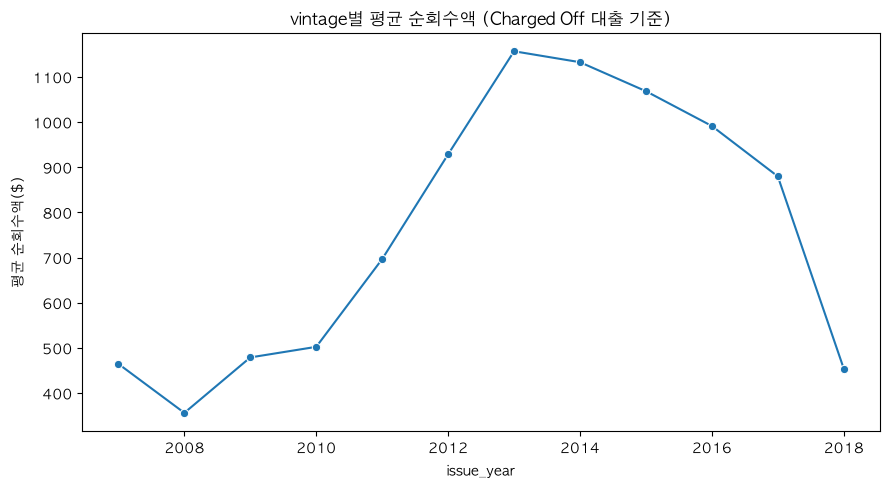

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(data=recovery_censoring, x='issue_year', y='avg_net_recovery', marker='o', ax=ax)
ax.set_title('vintage별 평균 순회수액 (Charged Off 대출 기준)')
ax.set_ylabel('평균 순회수액($)')
plt.tight_layout()
plt.show()

In [6]:
recovery_by_window = con.sql("""
    SELECT 
        DATE_DIFF('month', STRPTIME(last_pymnt_d, '%b-%Y'), DATE '2019-03-01') AS months_since_last_pymnt,
        AVG(recoveries - collection_recovery_fee) AS avg_net_recovery,
        COUNT(*) AS n
    FROM loans
    WHERE loan_status IN ('Charged Off', 'Does not meet the credit policy. Status:Charged Off')
      AND last_pymnt_d IS NOT NULL
    GROUP BY months_since_last_pymnt
    ORDER BY months_since_last_pymnt
""").df()

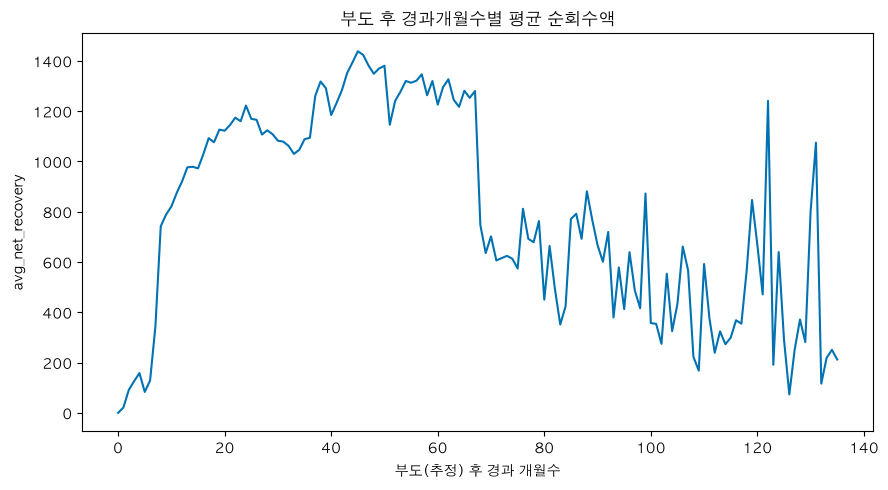

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(data=recovery_by_window, x='months_since_last_pymnt', y='avg_net_recovery', color='#0072B2', ax=ax)
ax.set_title('부도 후 경과개월수별 평균 순회수액')
ax.set_xlabel('부도(추정) 후 경과 개월수')
plt.tight_layout()
plt.show()

## 완결된 vintage 기준 손실율(LGD) 수준 파악

In [8]:
settlement_check = con.sql("""
    SELECT 
        CASE WHEN debt_settlement_flag = 'Y' THEN '채무조정 진행' ELSE '미진행' END AS settlement_group,
        COUNT(*) AS n,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct,
        ROUND(AVG(funded_amnt - total_rec_prncp), 2) AS avg_ead,
        ROUND(AVG(recoveries - collection_recovery_fee), 2) AS avg_net_recovery,
        ROUND(AVG(1 - (recoveries - collection_recovery_fee) / NULLIF(funded_amnt - total_rec_prncp, 0)), 3) AS avg_lgd
    FROM loans
    WHERE loan_status IN ('Charged Off', 'Does not meet the credit policy. Status:Charged Off')
    GROUP BY settlement_group
""").df()
settlement_check

,settlement_group,n,pct,avg_ead,avg_net_recovery,avg_lgd
0,미진행,230291,87.6,11218.67,854.88,0.925
1,채무조정 진행,32685,12.4,9717.04,2075.01,0.785


In [17]:
lgd_by_grade_year = con.sql("""
    SELECT issue_year, grade,
           COUNT(*) AS n,
           ROUND(AVG(funded_amnt - total_rec_prncp), 2) AS avg_ead,
           ROUND(AVG(recoveries - collection_recovery_fee), 2) AS avg_net_recovery,
           ROUND(1 - AVG(recoveries - collection_recovery_fee) / AVG(funded_amnt - total_rec_prncp), 3) AS lgd
    FROM loans
    WHERE loan_status IN ('Charged Off', 'Does not meet the credit policy. Status:Charged Off')
      AND issue_year BETWEEN 2011 AND 2017
      AND DATE_DIFF('month', STRPTIME(last_pymnt_d, '%b-%Y'), DATE '2019-03-01') >= 24
    GROUP BY issue_year, grade
    ORDER BY issue_year, grade
""").df()
lgd_by_grade_year

,issue_year,grade,n,avg_ead,avg_net_recovery,lgd
0,2011,A,366,4434.44,275.64,0.938
1,2011,B,788,6548.80,524.01,0.920
2,2011,C,709,7906.53,636.52,0.919
3,2011,D,639,8948.98,658.81,0.926
4,2011,E,465,11739.84,1004.49,0.914
5,2011,F,228,14718.68,1519.71,0.897
6,2011,G,64,16079.67,1158.08,0.928
7,2012,A,776,5870.42,434.88,0.926
8,2012,B,2376,6918.80,657.59,0.905
9,2012,C,2159,7807.54,737.06,0.906


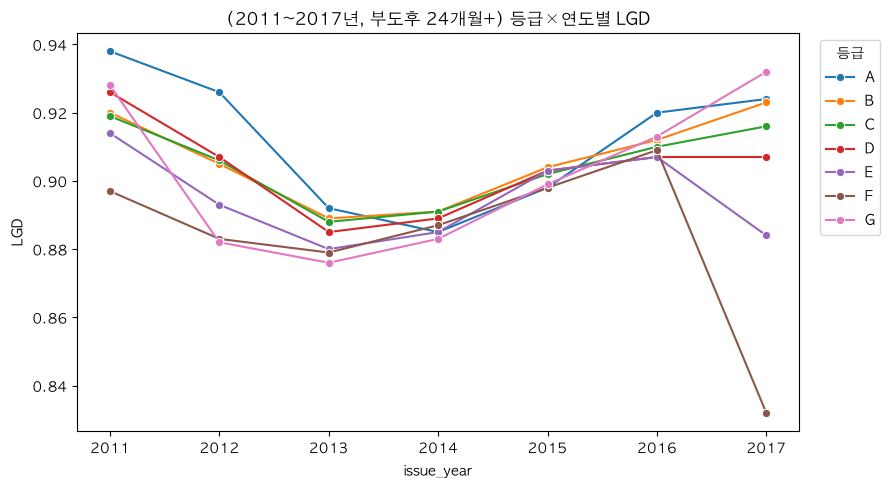

In [ ]:
# 2011, 2017년도는 표본 수가 적음
fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(data=lgd_by_grade_year, x='issue_year', y='lgd', hue='grade', marker='o', ax=ax)
ax.set_title('(2011~2017년, 부도후 24개월+) 등급×연도별 LGD')
ax.set_ylabel('LGD')
ax.legend(title='등급', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [19]:
final_lgd = con.sql("""
    SELECT 
           COUNT(*) AS n,
           SUM(funded_amnt - total_rec_prncp) AS total_ead,
           SUM(recoveries - collection_recovery_fee) AS total_net_recovery,
           ROUND(1 - SUM(recoveries - collection_recovery_fee) / SUM(funded_amnt - total_rec_prncp), 3) AS lgd_pooled
    FROM loans
    WHERE loan_status IN ('Charged Off', 'Does not meet the credit policy. Status:Charged Off')
      AND issue_year BETWEEN 2012 AND 2016
      AND DATE_DIFF('month', STRPTIME(last_pymnt_d, '%b-%Y'), DATE '2019-03-01') >= 24
""").df()
final_lgd

,n,total_ead,total_net_recovery,lgd_pooled
0,129991,1.511194e+09,1.546969e+08,0.898


In [20]:
lgd_by_year = con.sql("""
    SELECT issue_year,
           COUNT(*) AS n,
           ROUND(1 - SUM(recoveries - collection_recovery_fee) / SUM(funded_amnt - total_rec_prncp), 3) AS lgd_pooled
    FROM loans
    WHERE loan_status IN ('Charged Off', 'Does not meet the credit policy. Status:Charged Off')
      AND issue_year BETWEEN 2012 AND 2016
      AND DATE_DIFF('month', STRPTIME(last_pymnt_d, '%b-%Y'), DATE '2019-03-01') >= 24
    GROUP BY issue_year
    ORDER BY issue_year
""").df()
lgd_by_year

,issue_year,n,lgd_pooled
0,2012,8532,0.902
1,2013,20016,0.885
2,2014,35425,0.889
3,2015,46847,0.902
4,2016,19171,0.910


> # EAD 관련

- 대출 단위로 원금이 상환 중 증가하는 케이스가 있는가 (out_prncp/total_rec_prncp vs funded_amnt)
- (분석 단위는 member_id 전량 결측 확인으로 이미 "대출 단위"로 결정됨 — 별도 질문 아님)

## 대출 단위로 원금이 상환 중 증가하는 케이스가 있는가 (out_prncp/total_rec_prncp vs funded_amnt)

In [21]:
ead_check = con.sql("""
    SELECT
        SUM(CASE WHEN out_prncp > funded_amnt THEN 1 ELSE 0 END) AS n_out_prncp_exceed,
        SUM(CASE WHEN total_rec_prncp > funded_amnt THEN 1 ELSE 0 END) AS n_total_rec_prncp_exceed,
        COUNT(*) AS total_n
    FROM loans
""").df()
ead_check

,n_out_prncp_exceed,n_total_rec_prncp_exceed,total_n
0,0.0,136.0,2139958


In [22]:
overlap_check = con.sql("""
    SELECT loan_status, COUNT(*) AS n
    FROM loans
    WHERE total_rec_prncp > funded_amnt
    GROUP BY loan_status
    ORDER BY n DESC
""").df()
overlap_check

,loan_status,n
0,Fully Paid,132
1,Does not meet the credit policy. Status:Fully ...,4


## (분석 단위는 member_id 전량 결측 확인으로 이미 "대출 단위"로 결정됨 — 별도 질문 아님)

> # Rejected 간단 분석

In [29]:
con.execute("""
    CREATE OR REPLACE VIEW rejected AS
    SELECT 
        "Amount Requested" AS amount_requested,
        CAST("Application Date" AS DATE) AS app_date,
        Risk_Score AS risk_score,
        CAST(REPLACE("Debt-To-Income Ratio", '%', '') AS DOUBLE) AS dti
    FROM read_csv_auto('rejected_2007_to_2018Q4.csv')
""")

# 기간 확인
con.sql("SELECT MIN(app_date), MAX(app_date), COUNT(*) FROM rejected").show()
con.sql("SELECT COUNT(*) FROM rejected WHERE app_date >= '2013-11-05'").show()
con.sql("SELECT * FROM rejected WHERE app_date < '2013-11-05' LIMIT 5").show()

┌───────────────┬───────────────┬──────────────┐
│ min(app_date) │ max(app_date) │ count_star() │
│     date      │     date      │    int64     │
├───────────────┼───────────────┼──────────────┤
│ 2007-05-26    │ 2018-12-31    │     27648741 │
└───────────────┴───────────────┴──────────────┘

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│     26246702 │
└──────────────┘

┌──────────────────┬────────────┬────────────┬────────┐
│ amount_requested │  app_date  │ risk_score │  dti   │
│      double      │    date    │   double   │ double │
├──────────────────┼────────────┼────────────┼────────┤
│           1000.0 │ 2007-05-26 │      693.0 │   10.0 │
│           1000.0 │ 2007-05-26 │      703.0 │   10.0 │
│          11000.0 │ 2007-05-27 │      715.0 │   10.0 │
│           6000.0 │ 2007-05-27 │      698.0 │  38.64 │
│           1500.0 │ 2007-05-27 │      509.0 │   9.43 │
└──────────────────┴────────────┴────────────┴────────┘



In [24]:
compare_df = con.sql("""
    SELECT 'accepted' AS grp, (fico_range_low + fico_range_high)/2.0 AS score, dti
    FROM loans
    WHERE issue_d >= '2013-11-05'  -- issue_d가 문자열이면 아래처럼 STRPTIME 비교로 교체 필요
    USING SAMPLE 100000
    UNION ALL
    SELECT 'rejected' AS grp, risk_score AS score, dti
    FROM rejected
    WHERE app_date >= '2013-11-05'
    USING SAMPLE 100000
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

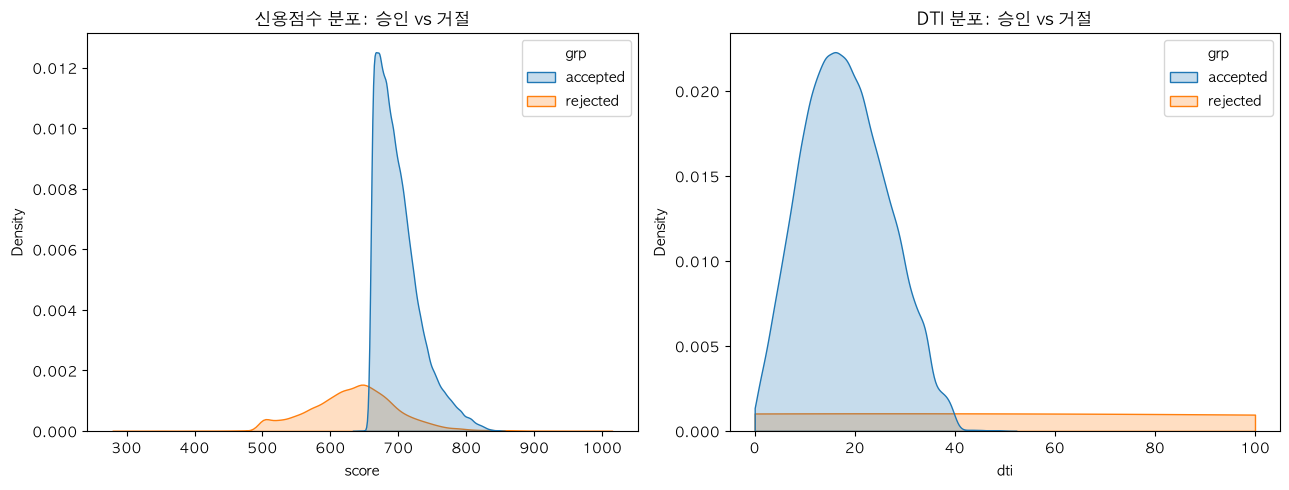

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.kdeplot(data=compare_df, x='score', hue='grp', fill=True, ax=axes[0])
axes[0].set_title('신용점수 분포: 승인 vs 거절')

sns.kdeplot(data=compare_df, x='dti', hue='grp', fill=True, ax=axes[1], clip=(0, 100))
axes[1].set_title('DTI 분포: 승인 vs 거절')
plt.tight_layout()
plt.show()

In [26]:
con.sql("""
    SELECT 
        MIN(dti), 
        APPROX_QUANTILE(dti, 0.5) AS median,
        APPROX_QUANTILE(dti, 0.95) AS p95,
        APPROX_QUANTILE(dti, 0.99) AS p99,
        MAX(dti),
        COUNT(*) AS n,
        SUM(CASE WHEN dti > 100 THEN 1 ELSE 0 END) AS n_over_100,
        SUM(CASE WHEN dti IS NULL THEN 1 ELSE 0 END) AS n_null
    FROM rejected
    WHERE app_date >= '2013-11-05'
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,min(dti),median,p95,p99,max(dti),n,n_over_100,n_null
0,-1.0,20.145875,100.0,483.864458,7374826.0,26246702,771652.0,0.0


In [27]:
compare_df = con.sql("""
    SELECT 'accepted' AS grp, (fico_range_low + fico_range_high)/2.0 AS score, dti
    FROM loans
    WHERE issue_d >= '2013-11-05' AND dti <= 100
    USING SAMPLE 100000
    UNION ALL
    SELECT 'rejected' AS grp, risk_score AS score, dti
    FROM rejected
    WHERE app_date >= '2013-11-05' AND dti <= 100
    USING SAMPLE 100000
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

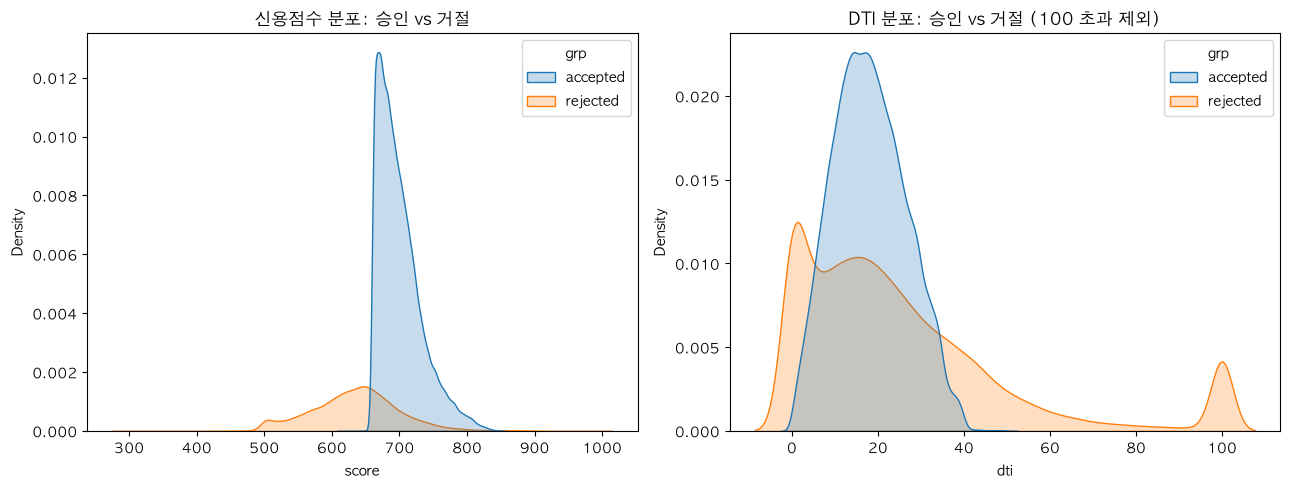

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.kdeplot(data=compare_df, x='score', hue='grp', fill=True, ax=axes[0])
axes[0].set_title('신용점수 분포: 승인 vs 거절')

sns.kdeplot(data=compare_df, x='dti', hue='grp', fill=True, ax=axes[1])
axes[1].set_title('DTI 분포: 승인 vs 거절 (100 초과 제외)')
plt.tight_layout()
# plt.savefig('images/6-1_rejected_accepted_분포비교.png', dpi=150, bbox_inches='tight')
plt.show()

---

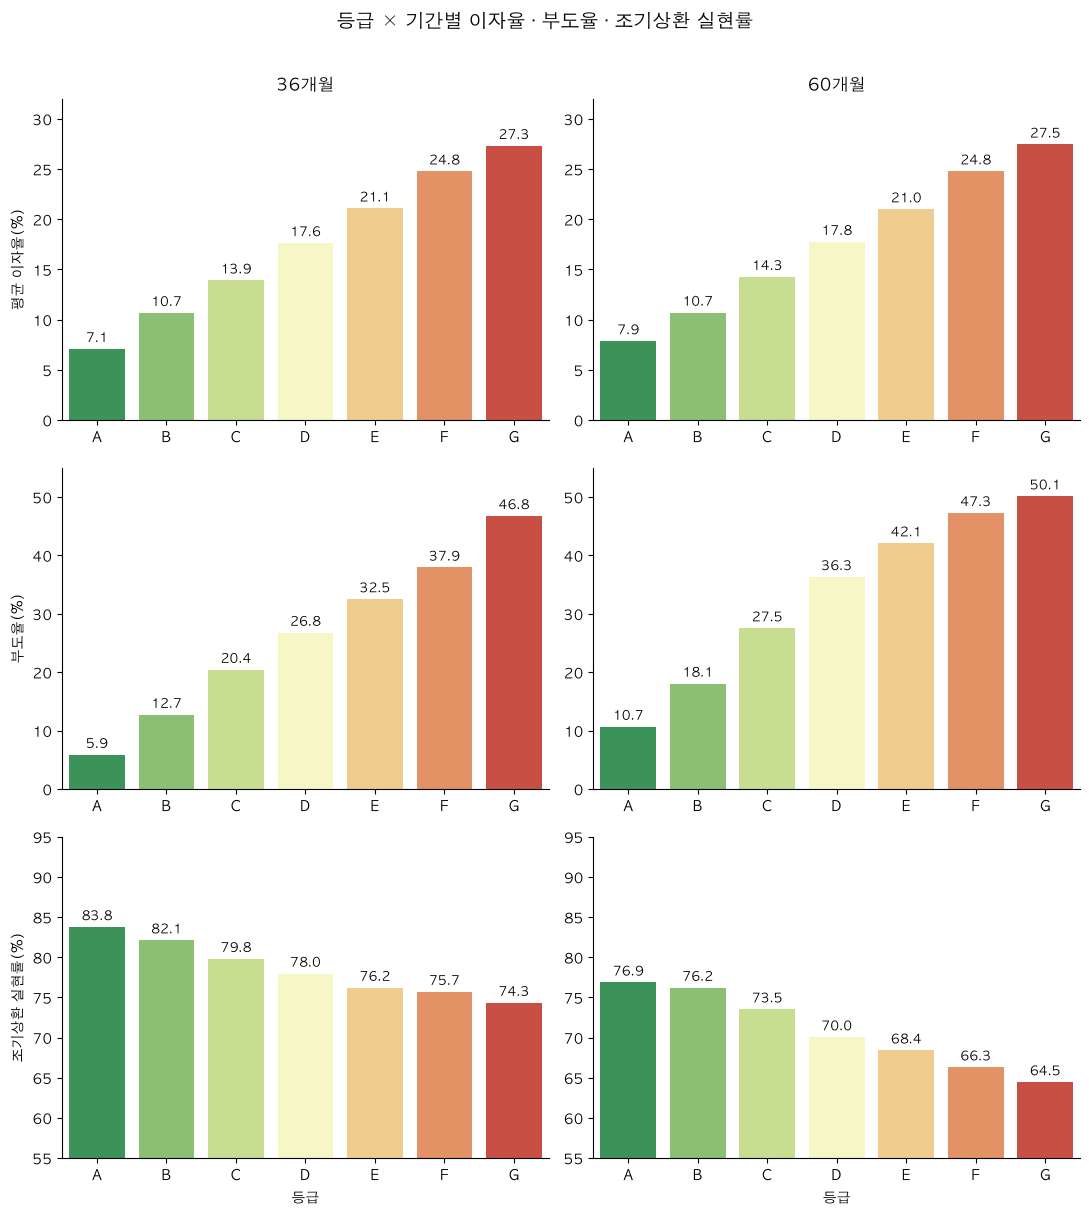

In [ ]:
# 1) 이자율 / 부도율: grade x term, 전체 기간 통합
grade_rate_default = con.sql("""
    SELECT grade, TRIM(term) AS term,
           COUNT(*) AS n,
           ROUND(AVG(int_rate), 2) AS avg_int_rate,
           ROUND(AVG(target) * 100, 2) AS default_rate_pct
    FROM loans_pd
    WHERE grade IS NOT NULL AND term IS NOT NULL
    GROUP BY grade, term
    ORDER BY grade, term
""").df()

# 2) 실현률: 만기 지난 완납 대출만, grade x term, 전체 기간 통합
#    (이미 위쪽 셀에서 grade_realization을 계산해뒀다면 그걸 재사용해도 됨 — 여기선 독립 실행 가능하도록 재계산)
grade_realization_recalc = con.sql("""
    WITH matured AS (
        SELECT *,
            CASE WHEN TRIM(term) = '36 months' THEN 36 ELSE 60 END AS term_months
        FROM loans_pd
        WHERE target = 0
    ),
    matured2 AS (
        SELECT *, STRPTIME(issue_d, '%b-%Y') AS issue_date
        FROM matured
    ),
    filtered AS (
        SELECT * FROM matured2
        WHERE issue_date + (term_months || ' months')::INTERVAL <= DATE '2019-03-01'
    ),
    amortized AS (
        SELECT *,
            int_rate/100.0/12 AS mr,
            (funded_amnt * (int_rate/100.0/12) * POWER(1+int_rate/100.0/12, term_months))
                / (POWER(1+int_rate/100.0/12, term_months) - 1) AS monthly_payment
        FROM filtered
    ),
    expected AS (
        SELECT *,
            monthly_payment * term_months - funded_amnt AS expected_interest_amortized,
            total_pymnt - funded_amnt AS actual_interest
        FROM amortized
    )
    SELECT grade, TRIM(term) AS term,
           COUNT(*) AS n,
           ROUND(100.0 * SUM(actual_interest) / SUM(expected_interest_amortized), 2) AS realization_pct
    FROM expected
    WHERE expected_interest_amortized > 0
    GROUP BY grade, term
    ORDER BY grade, term
""").df()

# 3) 3행(이자율/부도율/실현률) x 2열(36개월/60개월) 바 차트
grades = ['A','B','C','D','E','F','G']
palette = dict(zip(grades, sns.color_palette("RdYlGn_r", 7)))
terms = ['36 months', '60 months']
term_label = {'36 months': '36개월', '60 months': '60개월'}

metrics = [
    ('avg_int_rate', grade_rate_default, '평균 이자율(%)', (0, 32)),
    ('default_rate_pct', grade_rate_default, '부도율(%)', (0, 55)),
    ('realization_pct', grade_realization_recalc, '조기상환 실현률(%)', (55, 95)),
]

fig, axes = plt.subplots(3, 2, figsize=(11, 12))

for row, (col_name, df, ylabel, ylim) in enumerate(metrics):
    for col, term in enumerate(terms):
        ax = axes[row, col]
        sub = df[df['term'] == term].sort_values('grade')
        colors = [palette[g] for g in sub['grade']]
        sns.barplot(data=sub, x='grade', y=col_name, hue='grade',
                    palette=colors, legend=False, ax=ax)
        for c in ax.containers:
            ax.bar_label(c, fmt='%.1f', padding=2, fontsize=9)
        if row == 0:
            ax.set_title(term_label[term], fontsize=12)
        ax.set_ylim(*ylim)
        ax.set_xlabel('등급' if row == 2 else '')
        ax.set_ylabel(ylabel if col == 0 else '')
        sns.despine(ax=ax)

fig.suptitle('등급 × 기간별 이자율 · 부도율 · 조기상환 실현률', fontsize=14, y=1.01)
plt.tight_layout()
# plt.savefig('images/6-1_grade_term_이자율_부도율_실현률.png', dpi=150, bbox_inches='tight')
plt.show()